In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import itertools
import seaborn as sns
# import seaborn_image as isns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Set visualisation parameters
sns.set_context(
    "notebook", rc={"font.family": "sans-serif", "font.sans-serif": "Helvetica"}
)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]
plt.tight_layout()
sns.set(font_scale=2)
sns.set_style("ticks")

<Figure size 640x480 with 0 Axes>

# Visualisation Functions

In [3]:
def category_plotting(x, y, hue, data, order=[]):
    fig, ax = plt.subplots()
    sns.boxplot(
        x=x,
        y=y,
        hue=hue,
        data=data,
        order=order,
        palette=["Tab:red"],
        boxprops=dict(alpha=0.5),
        showcaps=False,
        showfliers=False,
        linewidth=1.7,
    )

    sns.swarmplot(
        x=x,
        y=y,
        hue=hue,
        data=data,
        order=order,
        dodge=True,
        palette=["Tab:red"],
        marker="o",
        size=3,
        linewidth=1,
        zorder=1,
        edgecolor="gray",
    )

    handles, labels = ax.get_legend_handles_labels()
    lgd = ax.legend(
        handles[0:2],
        labels[0:2],
        bbox_to_anchor=(1.05, 1),
        loc=2,
        borderaxespad=0,
        fontsize="large",
        handletextpad=0.5,
    )
    sns.despine()

    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, 0.5))

    return ax


def category_plotting_2(x, y, hue, data, ax, palette):
    sns.swarmplot(x=x, y=y, hue=hue, data=data, dodge=True, ax=ax, palette=palette)

    sns.barplot(x=x, y=y, hue=hue, data=data, alpha=0.7, ax=ax, palette=palette)

    sns.despine()
    handles, labels = ax.get_legend_handles_labels()
    # lgd = ax.legend(handles[0:2], labels[0:2],
    #                bbox_to_anchor=(1.05, 1), fontsize = 'medium',
    #                loc=2, borderaxespad=0,
    #                handletextpad = 0.5)
    lgd = ax.legend(
        handles[0:2],
        [],
        bbox_to_anchor=(1.05, 1),
        fontsize="medium",
        loc=2,
        borderaxespad=0,
        handletextpad=0.5,
    )


def paired_line(data, lines, column1, cond1_ls, column2, cond2, x_axis, colour="ro-"):
    plt.rcParams["figure.figsize"] = (3, 10)
    for i in range(len(lines)):
        line_data = data[data[column1] == cond1_ls[i]]
        if line_data[column2].item() == cond2:
            plt.plot(x_axis, lines[i], colour, alpha=0.8)
        else:
            plt.plot(x_axis, lines[i], "ko-", alpha=0.3)
    sns.despine()


def autolabel(g, list):
    i = 0
    for ax in g.axes.ravel():
        for p in ax.patches:
            ax.annotate(
                "n =" + str(list[i]),
                (p.get_x() + p.get_width() / 2.0, p.get_height()),
                ha="center",
                va="center",
                fontsize=13,
                color="black",
                xytext=(0, 8),
                textcoords="offset points",
            )
            i = i + 1


def autolabel_2(ax, list):
    i = 0
    for p in ax.patches:
        ax.annotate(
            "n = " + str(list[i]),
            (p.get_x() + p.get_width() / 2.0, 0),
            ha="center",
            va="center",
            xytext=(0, 12),
            textcoords="offset points",
            fontsize=14,
        )
        i = i + 1

# Statistics Functions

## Permutation and bootstrap tool

In [4]:
def itertool_stats(dict, method, key=None, ns=None):
    for subset in itertools.combinations(dict.keys(), 2):
        if method == "chi2_contingency":
            stat, p, dof, expected = stats.chi2_contingency(
                [
                    [dict[subset[0]], ns[subset[0]] - dict[subset[0]]],
                    [dict[subset[1]], ns[subset[1]] - dict[subset[1]]],
                ]
            )
            print(subset, p)
        elif method == "fisher":
            oddsratio, p = stats.fisher_exact([dict[subset[0]], dict[subset[1]]])
            print(subset, p)
        elif method == "ttest":
            stat, p = stats.ttest_ind(dict[subset[0]], dict[subset[1]], equal_var=False)
            print(subset, p)


def bootstrap(data, n=5, func=np.mean):
    """
    Generate `n` bootstrap samples, evaluating `func`
    at each resampling. `bootstrap` returns a function,
    which can be called to obtain confidence intervals
    of interest.
    """
    simulations = list()
    sample_size = len(data)
    xbar_init = np.mean(data)
    for c in range(n):
        itersample = np.random.choice(data, size=sample_size, replace=True)
        simulations.append(func(itersample))
    return simulations


def compute_conditional(data, con1, con1_parameter, con2, con2_parameter):
    agg_data = data[data[con1_parameter] == con1]
    parental_data = data[data[con2_parameter] == con2]
    union_data = agg_data[agg_data[con2_parameter] == con2]
    n = len(parental_data)
    if len(agg_data) == 0:
        return 0
    elif len(parental_data) == 0:
        return 0
    else:
        p = len(union_data) / len(parental_data)
        return p, n

# Data extraction and condition definition

In [5]:
data = pd.read_csv("data/negative_parental_switch_summary.csv", encoding="cp1252")
exp_conds = data["exp_cond"].unique()
# estrous_stages = data['estrous_stage'].unique()
estrous_stages = ["P", "E", "M", "D"]
agg_conds = ["all_stressor_5h", "food_deprivation"]

# Deprivation time

In [6]:
# set up dataframe
df = pd.read_csv("data/deprivation_time.csv")
df = df[df["valid"] != "invalid"]
count = df.groupby(["deprivation_duration"]).size().reset_index(name="count")
n = df.groupby(["deprivation_duration", "state_after"]).size().reset_index(name="n")
dep = count.merge(n, how="outer", on="deprivation_duration")
dep["percent"] = dep["n"] / dep["count"]
dep = dep[dep.state_after == "Agg+"]
dep = pd.concat(
    [
        dep,
        pd.DataFrame(
            {
                "deprivation_duration": 0,
                "count": 21,
                "state_after": "Agg+",
                "n": 0,
                "percent": 0,
            },
            index=[0],
        ),
    ]
)
dep["percent"] = dep["percent"] * 100

filtered_df = df.loc[:, ["deprivation_duration", "state_after"]]
filtered_df["state_after"] = filtered_df["state_after"].apply(
    lambda x: 1 if x == "Agg+" else 0
)
print(dep)

   deprivation_duration  count state_after   n    percent
1                   120     26        Agg+   4  15.384615
3                   180     16        Agg+   9  56.250000
5                   240     11        Agg+   7  63.636364
7                   360    133        Agg+  70  52.631579
0                     0     21        Agg+   0   0.000000


In [7]:
def logistic(x, A, x0, k, off):
    return A / (1 + np.exp(-k * (x - x0))) + off

In [8]:
x = filtered_df["deprivation_duration"]
y = filtered_df["state_after"]

# Systematically determine initial guesses
A_guess = np.max(y)  # Amplitude is roughly the max value of y
x0_guess = np.median(x)  # Midpoint is around the median of x
k_guess = 1 / (np.max(x) - np.min(x))  # Inverse of the range of x as a guess for slope
off_guess = np.min(y)  # Offset is roughly the minimum value of y

p0 = [A_guess, x0_guess, k_guess, off_guess]

popt, pcov = curve_fit(logistic, x, y, p0=p0)

residuals = y - logistic(x, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

0.36463782834281777


In [9]:
from scipy.stats import f

# Compute RSS for the full and null models
rss_full = np.sum((y - logistic(x, *popt)) ** 2)
rss_null = np.sum((y - np.mean(y)) ** 2)

# Degrees of freedom
k = len(popt)  # Number of parameters
n = len(y)  # Number of data points
df_model = k - 1
df_residual = n - k

# F-statistic
f_stat = ((rss_null - rss_full) / df_model) / (rss_full / df_residual)

# p-value
p_value_overall = 1 - f.cdf(f_stat, df_model, df_residual)
print(f"F-Statistic: {f_stat}")
print(f"Overall p-value: {p_value_overall}")

F-Statistic: 69.44256236470919
Overall p-value: 1.1102230246251565e-16


(-5.0, 5.0)

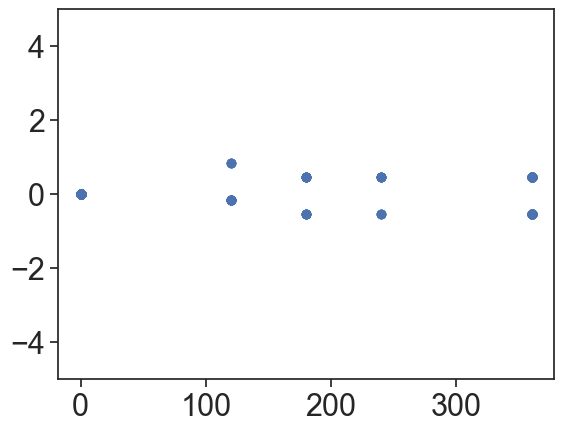

In [10]:
# indicate taht residual is not normally distributed and centre around 0
plt.plot(x, residuals, "o")
plt.ylim(-5, 5)

Text(0.5, 0, 'Time (min)')

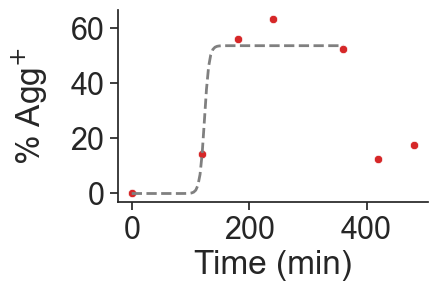

In [11]:
sns.set(font_scale=2)
sns.set_style("ticks")
plt.subplots(figsize=[4, 2.5])

# x = dep['deprivation_duration'][:5]
x = filtered_df["deprivation_duration"]
plot_x = np.linspace(x.min() - 0.4, x.max(), 100)
plt.plot(
    plot_x, logistic(plot_x, *popt) * 100, linewidth=2, linestyle="dashed", color="gray"
)

dep = pd.read_csv("data/dep_test.csv")
sns.scatterplot(data=dep, x="deprivation_duration", y="percent", color="Tab:red")
sns.despine()
# plt.ylim(-5,60)
plt.yticks(np.arange(0, 61, 20))
plt.ylabel(r"% Agg$^{+}$", labelpad=15)

plt.xlabel("Time (min)")
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/deprivation_time_refeed.pdf',
#             bbox_inches='tight', transparent=True)

In [12]:
# chi-square statistics
# 0-360 statistics
food_dep = dep[dep["deprivation_duration"] < 420]
chi2, p, dof, expected = stats.chi2_contingency(
    [food_dep["n"], food_dep["count"] - food_dep["n"]]
)
print(chi2, p)

# 360 - 480 statistics
refed_dep = dep[dep["deprivation_duration"] >= 360]
chi2, p, dof, expected = stats.chi2_contingency(
    [refed_dep["n"], refed_dep["count"] - refed_dep["n"]]
)
print(chi2, p)

27.99394559844473 1.2508221224651907e-05
15.084032706199888 0.0005303272160768449


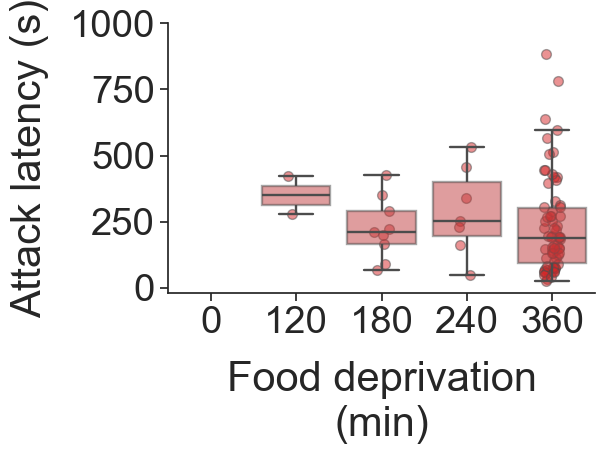

In [13]:
sns.set(rc={"figure.figsize": (5.5, 3.5)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

at = sns.stripplot(
    x="deprivation_duration",
    y="state_after_latency",
    data=df,
    color="tab:red",
    alpha=0.5,
    zorder=1,
    edgecolor="gray",
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
)
at = sns.boxplot(
    x="deprivation_duration",
    y="state_after_latency",
    data=df,
    color="tab:red",
    showfliers=False,
    linewidth=1.7,
    boxprops=dict(alpha=0.5),
)


at.set_ylabel("Attack latency (s)", labelpad=15)
at.set_xlabel("Food deprivation\n(min)", labelpad=15)
at.yaxis.set_major_locator(plt.MaxNLocator(5))
plt.ylim(top=1000)
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/deprivation_time_latency.pdf',
#             dpi=600, bbox_inches='tight', transparent=True)

In [14]:
df["state_after_latency"] = pd.to_numeric(df["state_after_latency"], errors="coerce")
df["deprivation_duration"] = df["deprivation_duration"].astype("category")

# Filter out the group with 0 hours of food deprivation
df_filtered = df[df["deprivation_duration"] != "0"]

# Fit the ANOVA model on the filtered data
model = smf.ols("state_after_latency ~ C(deprivation_duration)", data=df_filtered).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)

# Check if the ANOVA is significant
if anova_results["PR(>F)"][0] < 0.05:
    print(
        "The ANOVA is significant, indicating a relationship between food deprivation duration and attack latency."
    )
else:
    print(
        "The ANOVA is not significant, indicating no relationship between food deprivation duration and attack latency."
    )

                               sum_sq    df          F        PR(>F)
C(deprivation_duration)  5.009957e+06   4.0  41.148808  4.661757e-19
Residual                 2.556796e+06  84.0        NaN           NaN
The ANOVA is significant, indicating a relationship between food deprivation duration and attack latency.


In [15]:
# based on deprivation time, given that animal switch to be aggressive, what is the estrous cycle stage?
agg_df = df[df.state_after == "Agg+"]
estrous_dep = pd.crosstab(
    agg_df["deprivation_duration"], agg_df["estrous_stage"], margins=True
).reset_index()
estrous_dep.iloc[:, 1:5] = estrous_dep.iloc[:, 1:5].div(estrous_dep.All, axis=0) * 100
estrous_dep = estrous_dep.iloc[:-1, :-1]
cols = ["deprivation_duration", "P", "E", "M", "D"]
estrous_dep = estrous_dep[cols]

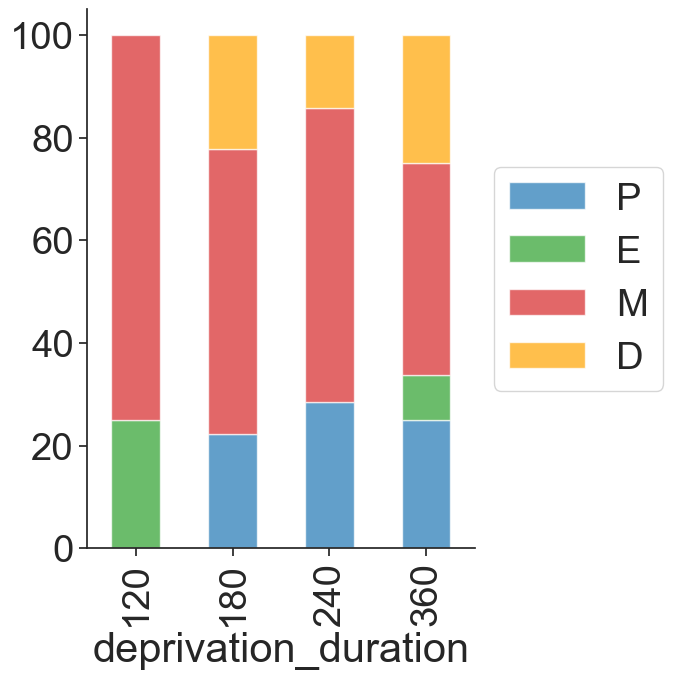

In [16]:
estrous_dep.plot(
    x="deprivation_duration",
    kind="bar",
    stacked=True,
    mark_right=False,
    color=["Tab:blue", "Tab:green", "Tab:red", "orange"],
    figsize=(5, 7),
    alpha=0.7,
)

ax = plt.gca()
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
# plt.savefig("output_figures/deprivation_time_hormone.jpeg", dpi=300)

In [17]:
# how is switching probability differ in different estrous cyle per deprivation duration --> proportion plateau
df = pd.read_csv("data/deprivation_time.csv")
count = (
    df.groupby(["deprivation_duration", "estrous_stage"], dropna=False)
    .size()
    .unstack()
    .fillna(0)
    .stack()
    .reset_index(name="count")
    .dropna()
)
n = (
    df.groupby(["deprivation_duration", "estrous_stage", "state_after"], dropna=False)
    .size()
    .unstack()
    .fillna(0)
    .stack()
    .reset_index(name="n")
    .dropna()
)
est_prop = count.merge(n, how="outer", on=["deprivation_duration", "estrous_stage"])
est_prop["percent"] = est_prop["n"] / est_prop["count"] * 100
est_prop = est_prop.fillna(0)
est_prop["estrous_stage"] = pd.Categorical(
    est_prop["estrous_stage"], ["P", "E", "M", "D"]
)
est_prop["deprivation_duration"] = pd.Categorical(
    est_prop["deprivation_duration"], [0, 120, 180, 240, 360]
)

est_prop = est_prop.sort_values(by=["deprivation_duration", "estrous_stage"])

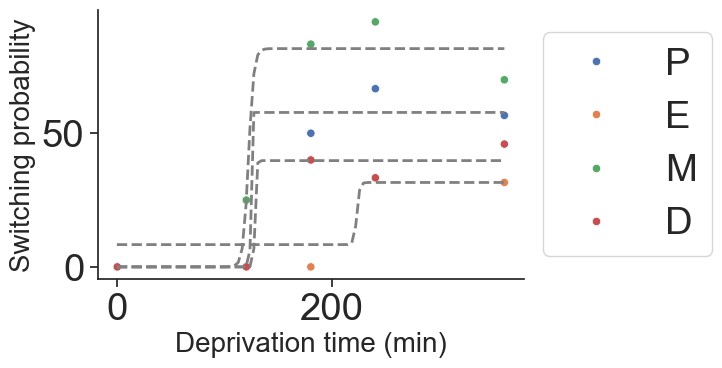

In [18]:
sns.scatterplot(
    data=est_prop[est_prop.state_after == "Agg+"],
    x="deprivation_duration",
    y="percent",
    hue="estrous_stage",
    color="Tab:red",
)
As = {}
for stage in est_prop.estrous_stage.unique():
    fit_df = est_prop[
        (est_prop.state_after == "Agg+") & (est_prop.estrous_stage == stage)
    ]

    x = fit_df["deprivation_duration"].astype(int)
    y = fit_df["percent"].astype(float)

    try:
        # control for runtime error
        popt, pcov = curve_fit(logistic, x, y, p0=[50, 185, 0.1, 0])
    except RuntimeError:
        continue
    As[stage] = popt[0]
    plot_x = np.linspace(x.min() - 0.4, x.max(), 100)
    plt.plot(
        plot_x, logistic(plot_x, *popt), linewidth=2, linestyle="dashed", color="gray"
    )
    plt.xlabel("Deprivation time (min)", fontsize=20)
    plt.ylabel("Switching probability", fontsize=20)
sns.despine()
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
# plt.savefig("output_figures/deprivation_time_hormone_SP.jpeg", dpi=300)

# Environmental Factors for NPS Probability

In [19]:
bootstrap_sample = {}
sample = {}

for con in exp_conds:
    if con == "food_deprivation":
        con_data = data[data["exp_cond"] == con][data["exp_time"] == 1][
            data["target"] == "cricket"
        ]
        con_data = con_data[con_data["exp_time"] == 1]
        con_data_binary = np.where(con_data.state_after.values == "Agg+", 1, 0)
        bootstrap_sample[con] = bootstrap(con_data_binary)
        sample[con] = [
            len(con_data[con_data.state_after == "Agg+"]),
            len(con_data[con_data.state_after == "Agg-"]),
        ]
    else:
        con_data = data[data["exp_cond"] == con][data["exp_time"] == 1][
            data["target"] == "pup"
        ]
        con_data = con_data[con_data["exp_time"] == 1]
        con_data_binary = np.where(con_data.state_after.values == "Agg+", 1, 0)
        bootstrap_sample[con] = bootstrap(con_data_binary)
        sample[con] = [
            len(con_data[con_data.state_after == "Agg+"]),
            len(con_data[con_data.state_after == "Agg-"]),
        ]

## stats comparing proportion of Agg+ mice experiencing different environmental conditions

In [20]:
# chi2_contingency

test_df = pd.DataFrame(sample)
stats.chi2_contingency(
    test_df.loc[
        :,
        [
            "all_stressor_6h",
            "food_deprivation",
            "water_deprivation",
            "light_cycle_disturbed",
            "novel_env",
            "all_stressor_plus_food",
        ],
    ]
)

Chi2ContingencyResult(statistic=30.473486842105267, pvalue=1.1898286106365005e-05, dof=5, expected_freq=array([[ 4.4057971 ,  4.4057971 ,  2.20289855,  3.02898551,  2.75362319,
         2.20289855],
       [11.5942029 , 11.5942029 ,  5.79710145,  7.97101449,  7.24637681,
         5.79710145]]))

## visualization of environmental condition based probability of mice turning to be aggressive

In [21]:
# compute agg proportion for each condition
agg_plus_proportion = {}
agg_minus_proportion = {}
ns = {}

for con in exp_conds:
    if con == "all_stressor_2h":
        pass
    elif con == "food_deprivation":
        con_data = data[data["exp_cond"] == con][data["exp_time"] == 1][
            data["target"] == "cricket"
        ]
        ns[con] = len(con_data)
        row_count = len(con_data)
        agg_count = len(con_data[con_data["state_after"] == "Agg+"])
        agg_plus_proportion[con] = agg_count / row_count * 100
        agg_minus_proportion[con] = 100 - agg_plus_proportion[con]

    else:
        con_data = data[data["exp_cond"] == con][data["exp_time"] == 1][
            data["target"] == "pup"
        ]
        ns[con] = len(con_data)
        row_count = len(con_data)
        agg_count = len(con_data[con_data["state_after"] == "Agg+"])
        agg_plus_proportion[con] = agg_count / row_count * 100
        agg_minus_proportion[con] = 100 - agg_plus_proportion[con]

print(agg_plus_proportion)

{'all_stressor_6h': 56.25, 'food_deprivation': 62.5, 'water_deprivation': 0.0, 'light_cycle_disturbed': 0.0, 'novel_env': 0.0, 'all_stressor_plus_food': 0.0}


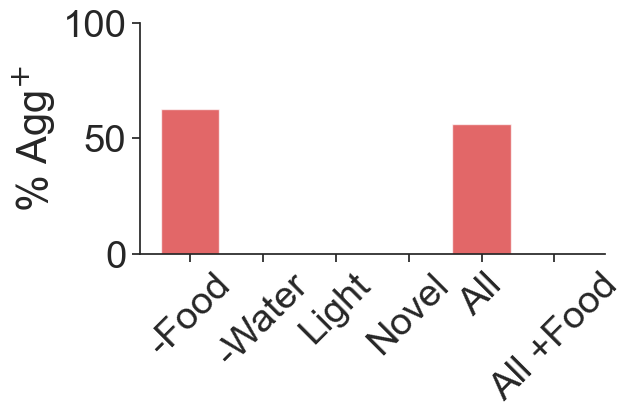

In [22]:
sns.set(rc={"figure.figsize": (6, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

order = [
    "food_deprivation",
    "water_deprivation",
    "light_cycle_disturbed",
    "novel_env",
    "all_stressor_6h",
    "all_stressor_plus_food",
]
values = [agg_plus_proportion[key] for key in order]
plt.bar(
    range(len(values)),
    values,
    tick_label=order,
    align="center",
    color="tab:red",
    alpha=0.7,
)
plt.xlabel(None)
plt.ylabel(r"% Agg$^{+}$")

locs, labels = plt.xticks()
plt.xticks(locs, ["-Food", "-Water", "Light", "Novel", "All", "All +Food"])
plt.xticks(rotation=45)
plt.ylim(0, 100)
sns.despine()

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/hunger.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

In [23]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# access counts for agg / non-agg for each condition
agg_plus_counts = {}
agg_minus_counts = {}
total_counts = {}

for con in exp_conds:
    if con == "all_stressor_2h":
        pass
    elif con == "food_deprivation":
        con_data = data[
            (data["exp_cond"] == con)
            & (data["exp_time"] == 1)
            & (data["target"] == "cricket")
        ]
        total_counts[con] = len(con_data)
        agg_plus_counts[con] = con_data[con_data["state_after"] == "Agg+"].shape[0]
        agg_minus_counts[con] = total_counts[con] - agg_plus_counts[con]
    else:
        con_data = data[
            (data["exp_cond"] == con)
            & (data["exp_time"] == 1)
            & (data["target"] == "pup")
        ]
        total_counts[con] = len(con_data)
        agg_plus_counts[con] = con_data[con_data["state_after"] == "Agg+"].shape[0]
        agg_minus_counts[con] = total_counts[con] - agg_plus_counts[con]

# Define groups for comparison
comparison_groups = ["food_deprivation"]

# Initialize dictionary to store results of Fisher's exact tests
results = {}

# Perform Fisher's exact test for each comparison
for group in comparison_groups:
    other_groups = [g for g in agg_plus_counts.keys() if g != group]
    for other_group in other_groups:
        table = [
            [agg_plus_counts[group], agg_minus_counts[group]],
            [agg_plus_counts[other_group], agg_minus_counts[other_group]],
        ]
        odds_ratio, p_value = fisher_exact(table)
        results[f"Fisher's exact test between '{group}' and '{other_group}'"] = {
            "odds_ratio": odds_ratio,
            "p_value": p_value,
        }

extra_table = [
    [agg_plus_counts["all_stressor_6h"], agg_minus_counts["all_stressor_6h"]],
    [
        agg_plus_counts["all_stressor_plus_food"],
        agg_minus_counts["all_stressor_plus_food"],
    ],
]
extra_odds_ratio, extra_p_value = fisher_exact(extra_table)
results[
    f"Fisher's exact test between 'all_stressor_6h' and 'all_stressor_plus_food'"
] = {"odds_ratio": extra_odds_ratio, "p_value": extra_p_value}
# Perform Benjamini-Hochberg correction
p_values = [result["p_value"] for result in results.values()]
corrected_p_values = multipletests(p_values, method="fdr_bh")[1]

# Update the results dictionary with corrected p-values
for i, (comparison, result) in enumerate(results.items()):
    result["corrected_p_value"] = corrected_p_values[i]

# Print corrected p-values
for comparison, result in results.items():
    print(f"{comparison}:")
    print(
        f"Odds Ratio: {result['odds_ratio']}, p-value: {result['p_value']}, Corrected p-value: {result['corrected_p_value']}"
    )
    print()

Fisher's exact test between 'food_deprivation' and 'all_stressor_6h':
Odds Ratio: 1.2962962962962963, p-value: 1.0, Corrected p-value: 1.0

Fisher's exact test between 'food_deprivation' and 'water_deprivation':
Odds Ratio: inf, p-value: 0.006428533551968739, Corrected p-value: 0.009642800327953109

Fisher's exact test between 'food_deprivation' and 'light_cycle_disturbed':
Odds Ratio: inf, p-value: 0.0010548481944362951, Corrected p-value: 0.006329089166617771

Fisher's exact test between 'food_deprivation' and 'novel_env':
Odds Ratio: inf, p-value: 0.002554532558570787, Corrected p-value: 0.0076635976757123605

Fisher's exact test between 'food_deprivation' and 'all_stressor_plus_food':
Odds Ratio: inf, p-value: 0.006428533551968739, Corrected p-value: 0.009642800327953109

Fisher's exact test between 'all_stressor_6h' and 'all_stressor_plus_food':
Odds Ratio: inf, p-value: 0.009495955652908138, Corrected p-value: 0.011395146783489764



# the effect of spontaneous state on NPS

## compute the probability of Agg+ mice depending on the spontaneous parental state

In [24]:
tar_data = data[
    data.target.isin(
        [
            "pup",
            "maze",
            "intruder",
            "cricket",
            "cfos",
            "refeeding_1h",
            "refeeding_2h",
            "openfield",
        ]
    )
]
agg_cond_data = pd.concat(
    [
        tar_data[tar_data["exp_cond"] == agg_conds[0]],
        tar_data[tar_data["exp_cond"] == agg_conds[1]],
    ]
)
agg_cond_data_first = agg_cond_data[agg_cond_data["exp_time"] == 1]

con_spon_ig, n_ig = compute_conditional(
    agg_cond_data_first, "Agg+", "state_after", "Parental-", "state_before"
)
con_spon_parental, n_parental = compute_conditional(
    agg_cond_data_first, "Agg+", "state_after", "Parental+", "state_before"
)
n = [n_ig, n_parental]
print(n)
print(con_spon_ig, con_spon_parental)

[62, 55]
0.5645161290322581 0.4727272727272727


In [25]:
# stats to see whether the spontaneous state differentially affect the likelihood of being aggressive
spon_df = agg_cond_data_first.copy()
# spon_df.loc[spon_df.state_after == 'Agg-', 'state_after'] = spon_df.loc[spon_df.state_after == 'Agg-', 'parental_state_after']
spon_table = pd.crosstab(spon_df.state_before, spon_df.state_after)
spon_chi, spon_p, dof, expected = stats.chi2_contingency(spon_table)
spon_table = spon_table.reset_index()
print(spon_table)
print(spon_chi, spon_p, dof)

state_after state_before  Agg+  Agg-
0              Parental+    26    29
1              Parental-    35    27
0.650562751962475 0.41991155289351767 1


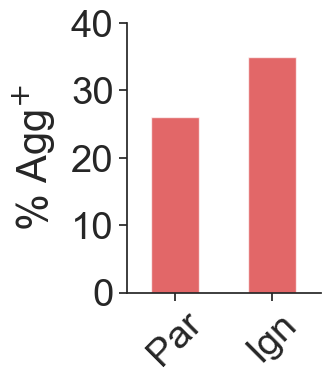

In [26]:
sns.set(rc={"figure.figsize": (2.5, 3.5)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

spon = spon_table.plot(
    x="state_before", y="Agg+", kind="bar", color=["Tab:red", "Tab:red"], alpha=0.7
)
spon.set_xticklabels(("Par", "Ign"), rotation=45)
plt.ylabel(r"% Agg$^{+}$", labelpad=10)
spon.set_xlabel("")
plt.ylim(top=40)
spon.yaxis.set_major_locator(plt.MaxNLocator(4))
spon.legend_.remove()
sns.despine()

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/spontaneous_state.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

# Estrous stages and NPS Probability

## impact of estrous cycle on the proportion of spontaneous parental and ignoring mice

In [27]:
est_spon_ig = {}
est_spon_parental = {}
n_spon_ig = {}
n_spon_parental = {}

data_est = tar_data[tar_data["exp_time"] == 1]

for estrous_stage in estrous_stages:
    est_data = data_est[data_est["estrous_stage"] == estrous_stage]
    est_data = est_data[est_data["exp_time"] == 1]
    est_spon_ig_data = est_data[est_data["state_before"] == "Parental-"]
    est_spon_parental_data = est_data[est_data["state_before"] == "Parental+"]
    est_spon_ig[estrous_stage] = len(est_spon_ig_data) / len(est_data)
    n_spon_ig[estrous_stage] = len(est_spon_ig_data)
    est_spon_parental[estrous_stage] = len(est_spon_parental_data) / len(est_data)
    n_spon_parental[estrous_stage] = len(est_spon_parental_data)

In [28]:
per_par_df = pd.crosstab(
    data_est.estrous_stage, tar_data.state_before, margins=True
).reset_index()
per_par_df = per_par_df[per_par_df.estrous_stage.isin(["P", "E", "M", "D"])]
chi2, p, dof, expected = stats.chi2_contingency(
    per_par_df.loc[:, ["Parental+", "Parental-"]]
)
print(chi2, p, dof)

1.196098987305663 0.7539400869468104 3


## plot proportion of mice being spontaneous parental or ignoring under different estrous cycle stage

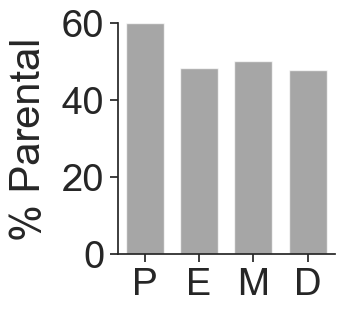

In [29]:
# convert dict to df, convert to %
est_spon_parental_df = pd.DataFrame([est_spon_parental]) * 100

sns.set(rc={"figure.figsize": (2.8, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.barplot(data=est_spon_parental_df, color="gray", width=0.7, alpha=0.7)
plt.ylabel("% Parental", labelpad=10)
spon.set_xlabel("")
plt.ylim(top=60)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine()

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_4/linked_figure_S4/estrous_switch.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

## impact of estrous cycle on the proportion of mice turning to be aggressive

In [30]:
estrous_data = {}
ns = {}
ns_spon_ig = {}
ns_spon_parental = {}
agg_latency = {}
est_con_spon_ig = {}
est_con_spon_parental = {}
len_agg = {}


for estrous_stage in estrous_stages:
    # proportion of mice turning to be aggressive at different estrous cycle stage
    est_data = agg_cond_data_first[
        agg_cond_data_first["estrous_stage"] == estrous_stage
    ]
    est_data_agg = est_data[est_data["state_after"] == "Agg+"]
    union_p = est_data_agg[est_data_agg["state_before"] == "Parental+"]
    union_m = est_data_agg[est_data_agg["state_before"] == "Parental-"]

    len_agg[estrous_stage] = len(est_data_agg)
    est_data_agg_latency = est_data_agg["state_after_latency"]
    est_prop = len(est_data_agg) / len(est_data) * 100
    estrous_data[estrous_stage] = est_prop
    ns[estrous_stage] = len(est_data)
    agg_latency[estrous_stage] = est_data_agg_latency

    # conditional propability of mice turning to be aggressivce at different estrous cycle stage
    est_con_spon_ig[estrous_stage] = compute_conditional(
        est_data, "Agg+", "state_after", "Parental-", "state_before"
    )[0]
    ns_spon_ig[estrous_stage] = len(est_data[est_data["state_before"] == "Parental-"])
    est_con_spon_parental[estrous_stage] = compute_conditional(
        est_data, "Agg+", "state_after", "Parental+", "state_before"
    )[0]
    ns_spon_parental[estrous_stage] = len(
        est_data[est_data["state_before"] == "Parental+"]
    )

print(estrous_data)
print(est_con_spon_ig)
print(est_con_spon_parental)
print(ns)
# estrous_data = pd.DataFrame.from_dict(estrous_data, orient = 'index')
# estrous_data.to_csv('generated_datasets/estrous_data.csv')

{'P': 55.55555555555556, 'E': 33.33333333333333, 'M': 68.57142857142857, 'D': 45.45454545454545}
{'P': 0.6923076923076923, 'E': 0.625, 'M': 0.65, 'D': 0.4444444444444444}
{'P': 0.42857142857142855, 'E': 0.0, 'M': 0.7333333333333333, 'D': 0.4666666666666667}
{'P': 27, 'E': 15, 'M': 35, 'D': 33}


## infer statistical power

In [31]:
stats.chi2_contingency(
    [
        [len_agg["P"], ns["P"] - len_agg["P"]],
        [len_agg["E"], ns["E"] - len_agg["E"]],
        [len_agg["M"], ns["M"] - len_agg["M"]],
        [len_agg["D"], ns["D"] - len_agg["D"]],
    ]
)

Chi2ContingencyResult(statistic=6.554147082561837, pvalue=0.08755136290272081, dof=3, expected_freq=array([[14.48181818, 12.51818182],
       [ 8.04545455,  6.95454545],
       [18.77272727, 16.22727273],
       [17.7       , 15.3       ]]))

In [32]:
pvalues = []
for subset in itertools.combinations(estrous_data.keys(), 2):
    stat, p = stats.fisher_exact(
        [
            [len_agg[subset[0]], ns[subset[0]] - len_agg[subset[0]]],
            [len_agg[subset[1]], ns[subset[1]] - len_agg[subset[1]]],
        ]
    )
    pvalues.append(p)
    print(subset, stat, p)

from statsmodels.stats.multitest import multipletests

_, corrected_p_values, _, _ = multipletests(pvalues, method="fdr_bh")
print("Corrected p-values:", corrected_p_values)

('P', 'E') 2.5 0.20865434603598956
('P', 'M') 0.5729166666666666 0.42680150737768696
('P', 'D') 1.5 0.6042080137327137
('E', 'M') 0.22916666666666666 0.029936484509897922
('E', 'D') 0.6 0.5347385739126124
('M', 'D') 2.618181818181818 0.08537095907557049
Corrected p-values: [0.41730869 0.60420801 0.60420801 0.17961891 0.60420801 0.25611288]


## plot proportion turning to be aggressive vs estrous stages

In [33]:
estrous_data

{'P': 55.55555555555556,
 'E': 33.33333333333333,
 'M': 68.57142857142857,
 'D': 45.45454545454545}

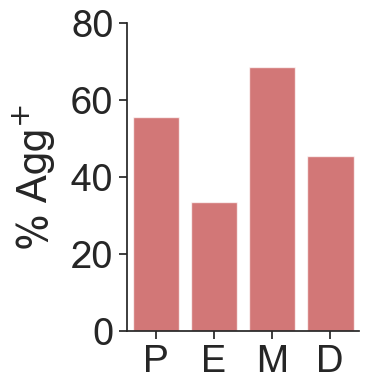

In [34]:
sns.set(font_scale=2.5)
sns.set_style("ticks")

fig, ax = plt.subplots(figsize=(3, 4))
estrous_df = pd.DataFrame.from_dict(estrous_data, orient="index")
estrous_df = estrous_df.reset_index()

estrous_df.columns = ['estrous_stage', 'percent']


sns.barplot(
    data=estrous_df, x="estrous_stage", y="percent", color="Tab:red", alpha=0.7, ax=ax
)

plt.xlabel("")
plt.ylabel(r"% Agg$^{+}$", labelpad=10)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 80)
# ax.tick_params(bottom=False)
sns.despine(bottom=False, trim=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/estrous_cycle.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)


## plot conditional probability of mice turning to be aggressivce 

In [35]:
for stage in estrous_stages:
    est_data = agg_cond_data_first[agg_cond_data_first["estrous_stage"] == stage]
    tab = pd.crosstab(est_data.state_before, est_data.state_after)
    odds, p = stats.fisher_exact(tab)
    print(stage, p)

P 0.2518598285996321
E 0.02564102564102564
M 0.7210233592880977
D 1.0


## plot aggression latency vs estrous stages

In [36]:
tab_agg_latency = {}
for i in estrous_stages:
    tab_agg_latency[i] = agg_cond_data_first[agg_cond_data_first["estrous_stage"] == i][
        "state_after_latency"
    ].dropna()

itertool_stats(tab_agg_latency, "ttest")

('P', 'E') 0.6644706227736692
('P', 'M') 0.9370392584914267
('P', 'D') 0.6347489067690044
('E', 'M') 0.639027724806483
('E', 'D') 0.8255227898540394
('M', 'D') 0.5462535649465422


In [37]:
stats.f_oneway(
    tab_agg_latency["P"],
    tab_agg_latency["E"],
    tab_agg_latency["M"],
    tab_agg_latency["D"],
)

F_onewayResult(statistic=0.2935683132831892, pvalue=0.8298617822104949)

Text(0.5, 1.0, ' ')

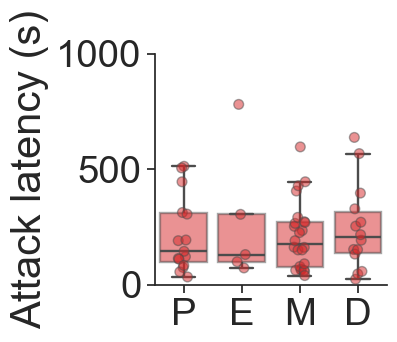

In [38]:
sns.set(rc={"figure.figsize": (3, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="estrous_stage",
    y="state_after_latency",
    data=agg_cond_data_first,
    order=["P", "E", "M", "D"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="estrous_stage",
    y="state_after_latency",
    data=agg_cond_data_first,
    order=["P", "E", "M", "D"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red"],
    alpha=0.5,
)

ax.set_xlabel("")
ax.set_ylabel("Attack latency (s)", labelpad=5)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1000)
sns.despine(bottom=False)
plt.title(" ", pad = 10)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_4/linked_figure_S4/estrous_latency.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

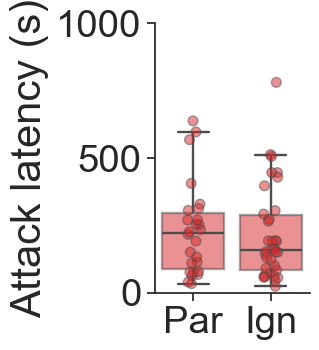

In [39]:
plt.subplots(figsize=(2, 3.5))
ax = sns.boxplot(
    x="state_before",
    y="state_after_latency",
    data=agg_cond_data_first,
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red"],
    order=["Parental+", "Parental-"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="state_before",
    y="state_after_latency",
    data=agg_cond_data_first,
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    order=["Parental+", "Parental-"],
    palette=["Tab:red"],
    alpha=0.5,
)

ax.set_xlabel("")
ax.set_xticklabels(["Par", "Ign"])
ax.set_ylabel("Attack latency (s)", labelpad=5)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1000)
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/spontaneous_latency.pdf', dpi=300,bbox_inches='tight', transparent=True)

In [40]:
stats.mannwhitneyu(
    agg_cond_data_first[agg_cond_data_first["state_before"] == "Parental+"][
        "state_after_latency"
    ].dropna(),
    agg_cond_data_first[agg_cond_data_first["state_before"] == "Parental-"][
        "state_after_latency"
    ].dropna(),
)

MannwhitneyuResult(statistic=480.5, pvalue=0.570786723620464)

# Relationship between P/E level and swiching probability 

## fit a function to the P/E curve

In [41]:
from scipy.optimize import curve_fit
from scipy.special import logit


# define function to be fitted
def func(x, a, b, c, d):
    return a * np.log(b * x / (1 - x) + c) + d

In [42]:
filtered_df = agg_cond_data_first.loc[:, ["estrous_stage", "state_after"]]

filtered_df["state_after"] = filtered_df["state_after"].apply(
    lambda x: 1 if x == "Agg+" else 0
)
hormone = pd.read_csv("hormone_level/hormone.csv")
hormone.rename(columns={"stage": "estrous_stage"}, inplace=True)
hormone_df = pd.merge(filtered_df, hormone)
hormone_df["P/E* 10^-3"] = hormone_df["P/E* 10^-3"] * 0.1


x = hormone_df["P/E* 10^-3"]
y = hormone_df["state_after"]

# Estimate initial guesses for p0
a_guess = (np.max(y) - np.min(y)) / 2
b_guess = 1 / (np.max(x) - np.min(x))
c_guess = 1  # Small positive value to avoid log(0)
d_guess = np.min(y)

p0 = [a_guess, b_guess, c_guess, d_guess]


popt, pcov = curve_fit(func, x, y, p0=p0)

residuals = y - func(x, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

0.058568777522239435


fitting for deprivation time 120
fitting not successful for time 120
fitting for deprivation time 180
fitting for deprivation time 240
fitting for deprivation time 360


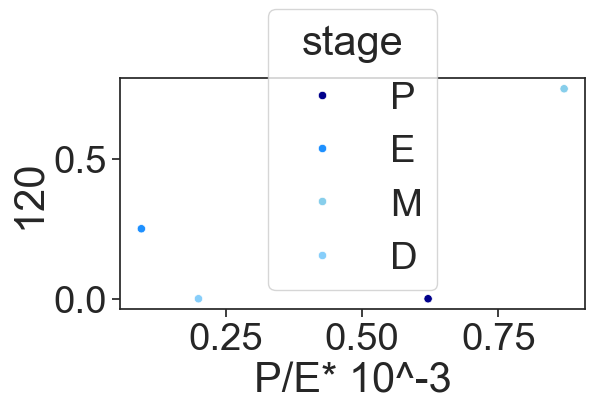

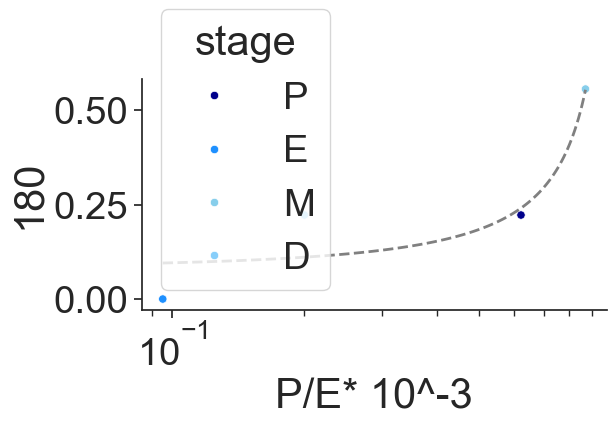

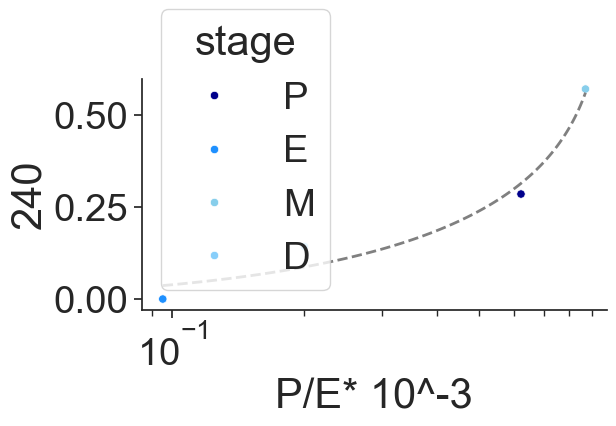

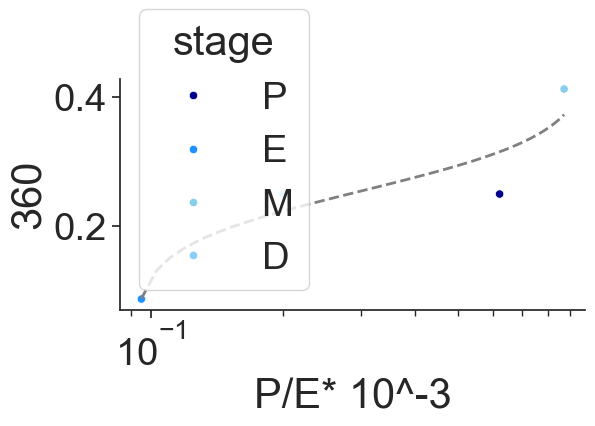

In [43]:
## temporary cells for tracing the effect of hormone on switching rate over time
hormone = pd.read_csv("hormone_level/hormone.csv")

columns = estrous_dep.T.reset_index().iloc[0][1:]
hormone_df = estrous_dep.T.iloc[1:, :]
hormone_df.columns = columns
hormone_df = hormone_df.reset_index()
hormone_df.rename(columns={"estrous_stage": "stage"}, inplace=True)
hormone_df = pd.merge(hormone_df, hormone)
hormone_df["P/E* 10^-3"] = hormone_df["P/E* 10^-3"] * 0.1

for time in columns.unique()[:]:
    hormone_df[time] = hormone_df[time] * 0.01

    try:
        print("fitting for deprivation time " + str(time))

        fig, ax = plt.subplots(figsize=(6, 3))
        sns.scatterplot(
            data=hormone_df,
            x="P/E* 10^-3",
            y=time,
            hue="stage",
            palette=["darkblue", "dodgerblue", "skyblue", "lightskyblue"],
        )

        x = hormone_df["P/E* 10^-3"]
        y = hormone_df[time]
        popt, pcov = curve_fit(func, x, y, p0=p0)

        plot_x = np.linspace(x.min(), x.max(), 100)
        plt.plot(
            plot_x, func(plot_x, *popt), linewidth=2, linestyle="dashed", color="gray"
        )
        plt.xscale("log")
        # plt.ylim([0,1])
        # plt.xlim([0.05,1])

        sns.despine()

    except RuntimeError:
        print("fitting not successful for time " + str(time))

In [44]:
filtered_df = agg_cond_data_first.loc[:, ["estrous_stage", "state_after"]]

filtered_df["state_after"] = filtered_df["state_after"].apply(
    lambda x: 1 if x == "Agg+" else 0
)
hormone = pd.read_csv("hormone_level/hormone.csv")
hormone.rename(columns={"stage": "estrous_stage"}, inplace=True)
hormone["P/E* 10^-3"] = hormone["P/E* 10^-3"] * 0.1
hormone_df = pd.merge(filtered_df, hormone)


x = hormone_df["P/E* 10^-3"]
y = hormone_df["state_after"]

# Estimate initial guesses for p0
a_guess = (np.max(y) - np.min(y)) / 2
b_guess = 1 / (np.max(x) - np.min(x))
c_guess = 1  # Small positive value to avoid log(0)
d_guess = np.min(y)

p0 = [a_guess, b_guess, c_guess, d_guess]


popt, pcov = curve_fit(func, x, y, p0=p0)

residuals = y - func(x, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

0.058568777522239435


In [48]:
# set up hormone state to include
preg = hormone[hormone.estrous_stage.isin(["PD10", "PD18"])]
virgin = hormone[hormone.estrous_stage.isin(["P", "E", "M", "D"])]

Text(0, 0.5, '% Agg$^{+}$')

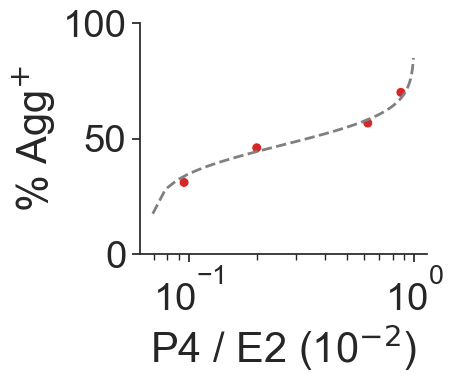

In [50]:
# %matplotlib inline
sns.set(rc={"figure.figsize": (3.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

# reset the hormone dataframe


ax = sns.scatterplot(
    data=virgin,
    x="P/E* 10^-3",
    y="switching probability",
    s=50,
    hue="estrous_stage",
    palette=["Tab:red", "Tab:red", "Tab:red", "Tab:red"],
    legend=False,
)  # darkblue', 'dodgerblue', 'skyblue', 'lightskyblue'


plot_x = np.linspace(0.05, 1, 100)
plt.plot(
    plot_x, func(plot_x, *popt) * 100, linewidth=2, linestyle="dashed", color="gray"
)


plt.xscale("log")
plt.xticks()
plt.yticks()
plt.ylim([0, 100])

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlabel(r"P4 / E2 (10$^{-2}$)")
ax.set_ylabel(r"% Agg$^{+}$")
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_2/linked_figure2/hormone_ratio.pdf',
# dpi=600,bbox_inches='tight', transparent=True)

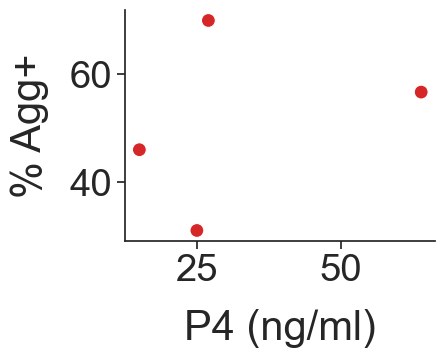

In [51]:
virgin["switching probability_percent"] = virgin["switching probability"]
sns.set(font_scale=2.5, style="ticks")
plt.subplots(figsize=(4, 3))
ax = sns.scatterplot(
    data=virgin,
    x="max_progesterone_level(ng/ml)",
    y="switching probability_percent",
    hue="estrous_stage",
    s=100,
    palette=["Tab:red"],
)
ax.set_ylabel("% Agg+", fontsize=30, labelpad=15)
ax.set_xlabel("P4 (ng/ml)", fontsize=30, labelpad=15)

# turn legend off
ax.legend_.remove()
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_4/linked_figure_S4/P4_corr.pdf', dpi = 300,bbox_inches='tight',transparent=True)

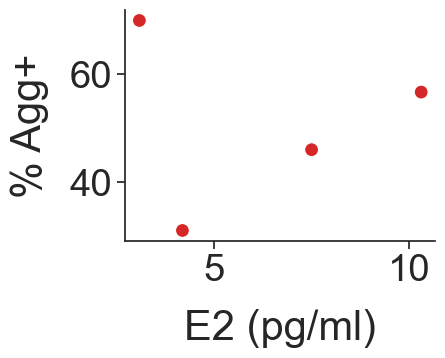

In [52]:
plt.subplots(figsize=(4, 3))
ax = sns.scatterplot(
    data=virgin,
    x="max_estrogen_level(pg/ml)",
    y="switching probability_percent",
    hue="estrous_stage",
    s=100,
    palette=["Tab:red"],
)
ax.set_ylabel("% Agg+", fontsize=30, labelpad=15)
ax.set_xlabel("E2 (pg/ml)", fontsize=30, labelpad=15)

ax.legend_.remove()
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_4/linked_figure_S4/E2_corr.pdf', dpi = 300,bbox_inches='tight', transparent=True)

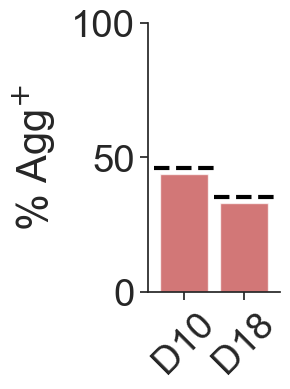

In [53]:
plt.subplots(figsize=(1.7, 3.5))
sns.set(font_scale=2.5)
sns.set_style("ticks")
preg["switching probability_percent"] = preg["switching probability"]

ax = sns.barplot(
    x="estrous_stage",
    y="switching probability_percent",
    data=preg,
    palette=["Tab:red", "Tab:red"],
    alpha=0.7,
)

i = 0
for stage in preg.estrous_stage.unique():
    v = preg[preg.estrous_stage == stage]["P/E* 10^-3"].values
    z = func(v[0], *popt) * 100
    plt.hlines(y=z, xmin=i - 0.5, xmax=i + 0.5, linestyle="dashed", color="black", lw=3)
    i += 1
plt.xticks(rotation=45)
plt.yticks()
plt.ylabel(r"% Agg$^{+}$", labelpad=10)  # $P_{S}$
plt.xlabel("")
ax.set_xticklabels(("D10", "D18"), rotation=45)
plt.ylim([0, 100])
sns.despine(bottom=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_2/linked_figure2/preg_switching_prediction.pdf',
# dpi=600,bbox_inches='tight', transparent=True)

# Receptor KO and NPS

In [54]:
from scipy.stats import binom
from poibin import PoiBin


def binomial_range(data, estrous_data):
    ps = []

    for i in data["estrous_stage"].unique():
        n = int(data[data["estrous_stage"] == i]["estrous_count"].iloc[0])
        p = estrous_data[i] * 0.01
        p = [p] * n

        ps.extend(p)

    # produce and return a poisson binomial pmf based on list of means from estrous cycle stages
    pb = PoiBin(ps)
    x = np.arange(0, int(data["estrous_count"].sum() / 2))
    dist = pb.cdf(x)
    pmf = pb.pmf(x)

    # get mean of the distibution
    mean = int(np.where(pmf == pmf.max())[0])  # most probable value
    std = np.sqrt(np.sum([i * j for i, j in zip([1 - p for p in ps], ps)]))
    mean_t = np.sum(ps)  # mean of the distribution

    # get the 0.05 interval
    lower = mean_t - 2 * std
    # lower = np.where(dist > 0.05)[0][0] # using distribution

    # get the 0.95 confidence interval
    higher = mean_t + 2 * std
    # higher = np.where(dist < 0.95)[0][-1] # using distribution

    return lower, higher, mean, pb

In [56]:
KO_dat = pd.read_csv("../NPS_hormone/receptor_KO/data/receptorKO.csv")

viruses = ["EGFP-CRE", "EGFP"]
areas = ["MPOA", "ARC"]
receptors = ["PR", "ESR"]

KO_dat = KO_dat[
    (KO_dat.injection_site.isin(areas))
    & (KO_dat.validation != "invalid")
    & (KO_dat.state_after != "invalid")
]

KO_count = (
    KO_dat.groupby(["KO", "injection_site", "virus", "state_after"])
    .size()
    .reset_index(name="count")
)
KO_n = KO_dat.groupby(["KO", "injection_site", "virus"]).size().reset_index(name="n")
KO_count = KO_count[KO_count.virus == "EGFP-CRE"]
KO_n = KO_n[KO_n.virus == "EGFP-CRE"]

c_count = (
    KO_dat.groupby(["injection_site", "virus", "state_after"])
    .size()
    .reset_index(name="count")
)
c_n = KO_dat.groupby(["injection_site", "virus"]).size().reset_index(name="n")
c_count = c_count[c_count.virus == "EGFP"]
c_n = c_n[c_n.virus == "EGFP"]

KO_n = pd.concat([KO_n, c_n])
KO_count = pd.concat([KO_count, c_count])

In [57]:
# calculate predicted probability of switching based on the number of animals in different estrous cycle stages

KO_df = KO_n.merge(KO_count, how="outer", on=["KO", "injection_site", "virus"])
KO_df["percent"] = KO_df["count"] / KO_df["n"] * 100


KO_probability = (
    KO_dat.groupby(["KO", "injection_site", "virus", "estrous_stage"])
    .size()
    .reset_index(name="estrous_count")
)
KO_probability = KO_probability[KO_probability.virus == "EGFP-CRE"]
c_probability = (
    KO_dat.groupby(["injection_site", "virus", "estrous_stage"])
    .size()
    .reset_index(name="estrous_count")
)
c_probability = c_probability[c_probability.virus == "EGFP"]
KO_probability = pd.concat([KO_probability, c_probability])

KO_probability = KO_probability.merge(
    KO_df, how="outer", on=["KO", "injection_site", "virus"]
)


for KO in receptors:
    for area in areas:
        for virus in viruses:

            if virus == "EGFP-CRE":
                cond = (
                    (KO_probability.injection_site == area)
                    & (KO_probability.KO == KO)
                    & (KO_probability.virus == virus)
                )

                KO_est = KO_probability[cond]

            else:
                cond = (KO_probability.injection_site == area) & (
                    KO_probability.virus == virus
                )

                KO_est = KO_probability[cond]

            if KO_est.empty:
                continue

            else:

                # input data to the poisson binomial distribution
                lower, higher, mean, pb = binomial_range(KO_est, estrous_data)

                KO_probability.loc[cond, "lower"] = lower
                KO_probability.loc[cond, "higher"] = higher
                KO_probability.loc[cond, "mean"] = mean
                p_right = pb.pval(KO_probability[cond]["count"].iloc[0])
                p_left = 1 - p_right
                KO_probability.loc[cond, "pvalue"] = min(p_right, p_left)


KO_probability.pop("estrous_stage")
KO_probability.pop("estrous_count")
KO_probability = KO_probability.drop_duplicates()


KO_probability["mean"] = KO_probability["mean"] / KO_probability["n"] * 100
KO_probability["lower"] = KO_probability["lower"] / KO_probability["n"] * 100
KO_probability["higher"] = KO_probability["higher"] / KO_probability["n"] * 100

print(KO_probability)

     KO injection_site     virus   n state_after  count     percent  \
0   ESR            ARC  EGFP-CRE  10        Agg+      5   50.000000   
1   ESR            ARC  EGFP-CRE  10        Agg-      5   50.000000   
8   ESR           MPOA  EGFP-CRE  10        Agg+     10  100.000000   
12   PR            ARC  EGFP-CRE  11        Agg+      7   63.636364   
13   PR            ARC  EGFP-CRE  11        Agg-      4   36.363636   
20   PR           MPOA  EGFP-CRE  13        Agg+      3   23.076923   
21   PR           MPOA  EGFP-CRE  13        Agg-     10   76.923077   
28  NaN           MPOA      EGFP  10        Agg+      7   70.000000   
29  NaN           MPOA      EGFP  10        Agg-      3   30.000000   

        lower     higher       mean    pvalue  
0   22.948989  83.221285  50.000000  0.294222  
1   22.948989  83.221285  50.000000  0.294222  
8   16.881503  78.021816  40.000000  0.000413  
12  24.576057  83.554600  54.545455  0.370121  
13  24.576057  83.554600  54.545455  0.370121  
2

40.0
53.84615384615385


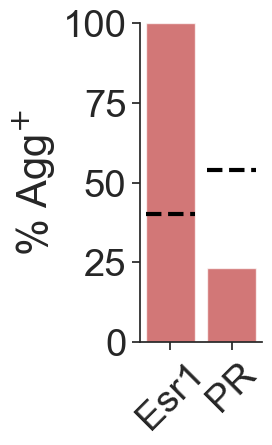

50.0


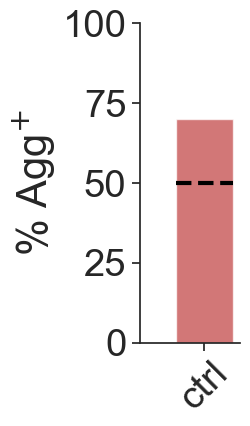

50.0
54.54545454545454


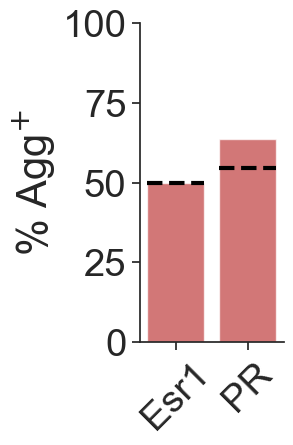

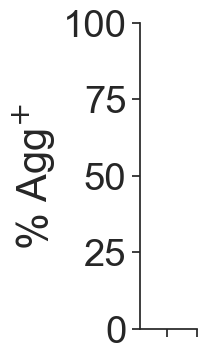

In [59]:
sns.set(font_scale=2.5)
sns.set_style("ticks")

conds = ["EGFP-CRE", "EGFP"]

for area in areas:

    for cond in conds:

        KO = KO_probability[
            (KO_probability.injection_site == area) & (KO_probability.virus == cond)
        ]

        KO = KO[KO.state_after == "Agg+"]

        try:

            if cond == "EGFP-CRE":

                g = sns.catplot(
                    x="KO",
                    y="percent",
                    kind="bar",
                    data=KO,
                    palette=["Tab:red", "Tab:red"],
                    aspect=10 / 15,
                    alpha=0.7,
                )
                plt.xlim(-0.5)
                ax = plt.gca()
                ax.set_xticklabels(["Esr1", "PR"], rotation=45)

            else:

                g = sns.catplot(
                    x="virus",
                    y="percent",
                    kind="bar",
                    data=KO,
                    palette=["Tab:red"],
                    aspect=8.7 / 15,
                    alpha=0.7,
                )
                plt.xlim(-0.9)
                ax = plt.gca()
                ax.set_xticklabels(["ctrl"], rotation=45)

            #             sns.set(rc={'figure.figsize':(5,1)})
            sns.set(font_scale=2.5)
            sns.set_style("ticks")

            plt.ylim([0, 100])
            #             autolabel(g, KO['n'].tolist())
            ax = plt.gca()
            ax.set_ylabel(r"% Agg$^{+}$")

            sns.despine(trim=False, bottom=False)
            #             ax.tick_params(bottom=False)

            # plot predicted switching probability based on estrous cycle the expriment mice are in
            xs = []

            for patch in ax.patches:

                width = patch.get_width()
                xs.append(patch.get_x())

            i = 0
            for x in xs:
                x_plot = np.linspace(x, x + width, 100)
                line = KO["mean"].iloc[i]
                y_plot = np.linspace(line, line, 100)
                print(line)

                i = i + 1
                plt.plot(
                    x_plot,
                    y_plot,
                    linestyle="dashed",
                    linewidth=3,
                    color="black",
                    label="Estrous stages\npredicted switching",
                )

            g.set(xlabel=None)  # area
            #             print(KO)

            # plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_2/linked_figure2/'
            #             + area + '_'+ cond + '_KO.pdf', dpi=300,bbox_inches='tight')
           
            plt.show()

        except ValueError:
            pass

# HCN block cannulation experiment (preliminary)

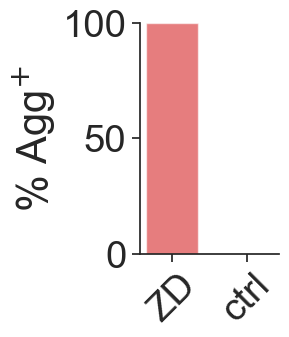

In [78]:
sns.set(font_scale=2.5)
sns.set_style("ticks")

estrous_data = {"ZD": 100, "ctrl": 0}

fig, ax = plt.subplots(figsize=(1.8, 3))

# Create the bar plot
bars = plt.bar(
    range(len(estrous_data)),
    list(estrous_data.values()),
    tick_label=list(estrous_data.keys()),
    align="center",
    color="tab:red",
    width=0.7,
    alpha=0.6,
)

plt.xlabel("")
plt.ylabel(r"% Agg$^{+}$")
ax.set_xticklabels(("ZD", "ctrl"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 100)
sns.despine(bottom=False, trim=False)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/HCN_cannulation.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

# Food intake Analysis

compare baseline, Agg+ and Agg- food intake and run statistics

In [60]:
food_intake = {}
food_intake["Pre"] = agg_cond_data_first["1h_food_consumption_before"].dropna().tolist()
food_intake["Agg+"] = (
    agg_cond_data_first[agg_cond_data_first["state_after"] == "Agg+"][
        "1h_food_consumption_after"
    ]
    .dropna()
    .tolist()
)
food_intake["Agg-"] = (
    agg_cond_data_first[agg_cond_data_first["state_after"] == "Agg-"][
        "1h_food_consumption_after"
    ]
    .dropna()
    .tolist()
)
food_intake["pup_absent"] = (
    data[data["target"] == "pup_absent"]["1h_food_consumption_after"].dropna().tolist()
)
food_df = pd.concat(
    [pd.DataFrame(food_intake[key], columns=[key]) for key in food_intake.keys()],
    axis=1,
)
food_df = food_df.melt(var_name="state", value_name="food_consumption").dropna()
plot_df = food_df.copy()
plot_df.loc[plot_df["state"].isin(["Agg+", "Agg-"]), "state"] = "Post"
plot_df = plot_df[plot_df.state.isin(["Pre", "Post"])]

In [61]:
stats.ttest_ind(
    plot_df[plot_df["state"] == "Pre"]["food_consumption"],
    plot_df[plot_df["state"] == "Post"]["food_consumption"],
)

TtestResult(statistic=-16.439980974270895, pvalue=3.479778942199893e-30, df=100.0)

plot food intake of baseline and that of Agg+ and Agg- mice after the state-changing period

In [62]:
state_counts = plot_df["state"].value_counts()
print(state_counts)

state
Post    62
Pre     40
Name: count, dtype: int64


Text(0.5, 1.0, ' ')

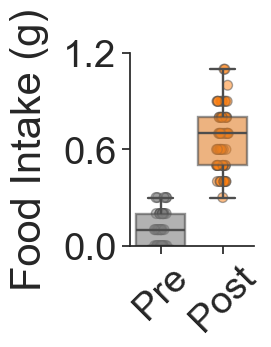

In [63]:
sns.set(rc={"figure.figsize": (1.6, 2.5)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.stripplot(
    x="state",
    y="food_consumption",
    data=plot_df,
    color="black",
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=1,
    jitter=True,
    palette=["gray", "Tab:orange"],
)
ax = sns.boxplot(
    x="state",
    y="food_consumption",
    data=plot_df,
    palette=["gray", "Tab:orange"],
    linewidth=1.7,
    showfliers=False,
    boxprops=dict(alpha=0.6),
)

ax.set_ylabel("Food Intake (g)", labelpad=10)
ax.set(xlabel="")

plt.xticks(rotation=45)
plt.ylim(0, 1.2)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine()
plt.title(" ", pad = 10)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/food_prepost.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

compare baseline, post phase Agg+, Parental+ and Parental- mice food intake and run statistics

In [64]:
food_intake_state_plot = {}
food_intake_state = {}

food_intake_state_plot["Agg+"] = agg_cond_data_first[
    agg_cond_data_first["state_after"] == "Agg+"
]["1h_food_consumption_after"]
food_intake_state_plot["Parental+"] = agg_cond_data_first[
    agg_cond_data_first["parental_state_after"] == "Parental+"
]["1h_food_consumption_after"]
food_intake_state_plot["Parental-"] = agg_cond_data_first[
    agg_cond_data_first["parental_state_after"] == "Parental-"
]["1h_food_consumption_after"]
food_intake_state["Agg+"] = food_intake_state_plot["Agg+"].dropna().tolist()
food_intake_state["Parental+"] = food_intake_state_plot["Parental+"].dropna().tolist()
food_intake_state["Parental-"] = food_intake_state_plot["Parental-"].dropna().tolist()


stats1, p1_s = stats.ttest_ind(
    food_intake_state["Agg+"], food_intake_state["Parental+"], equal_var=False
)
stats2, p2_s = stats.ttest_ind(
    food_intake_state["Agg+"], food_intake_state["Parental-"], equal_var=False
)
stats3, p3_s = stats.ttest_ind(
    food_intake_state["Parental+"], food_intake_state["Parental-"], equal_var=False
)
print({key: len(value) for key, value in food_intake_state.items()})
print(p1_s, p2_s, p3_s)

{'Agg+': 32, 'Parental+': 19, 'Parental-': 10}
0.0024303631448219596 0.0029354400434227785 0.5189814241789504


invesgate how _food cycle affect the food intake before and after going through the state_changing period

In [65]:
# calculate the number of animals in each estrous cycle stage
agg_cond_data_first[agg_cond_data_first["1h_food_consumption_after"].notnull()][
    "estrous_stage"
].value_counts()

estrous_stage
D    20
M    17
P    14
E     9
Name: count, dtype: int64

In [66]:
response_var = "1h_food_consumption_before"
formula = f'Q("{response_var}") ~ estrous_stage'
model = smf.ols(formula, data=agg_cond_data_first).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                 sum_sq    df         F    PR(>F)
estrous_stage  0.026353   3.0  0.867787  0.467263
Residual       0.344173  34.0       NaN       NaN


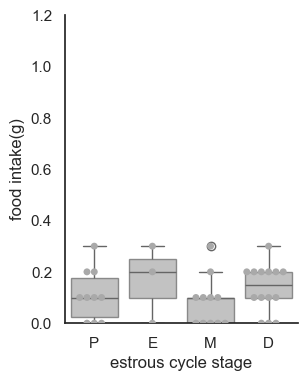

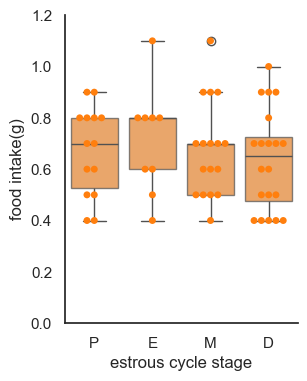

In [72]:
agg_cond_data_first.estrous_stage = pd.Categorical(
    agg_cond_data_first["estrous_stage"], ["P", "E", "M", "D"]
)
agg_cond_data_first.sort_values(by="estrous_stage")

sns.set(rc={"figure.figsize": (3, 4)})
sns.set_style("white")

plt.subplots()
sns.swarmplot(
    x="estrous_stage",
    y="1h_food_consumption_before",
    data=agg_cond_data_first,
    dodge=False,
    palette=['darkgray']
)

sns.boxplot(
    x="estrous_stage",
    y="1h_food_consumption_before",
    data=agg_cond_data_first,
    dodge=False,
    palette=["darkgray"],
    boxprops = {'alpha': 0.7}
)

plt.xlabel("estrous cycle stage")
plt.ylabel("food intake(g)")
plt.ylim([0, 1.2])
sns.despine()


plt.subplots()
sns.swarmplot(
    x="estrous_stage",
    y="1h_food_consumption_after",
    data=agg_cond_data_first,
    dodge=False,
    palette=["Tab:orange"],
)

sns.boxplot(
    x="estrous_stage",
    y="1h_food_consumption_after",
    data=agg_cond_data_first,
    dodge=False,
    palette=["Tab:orange"],
    boxprops = {'alpha': 0.7}
)

plt.ylim([0, 1.2])

plt.xlabel("estrous cycle stage")
plt.ylabel("food intake(g)")
sns.despine()

plotting correlation between food intake and attack latency

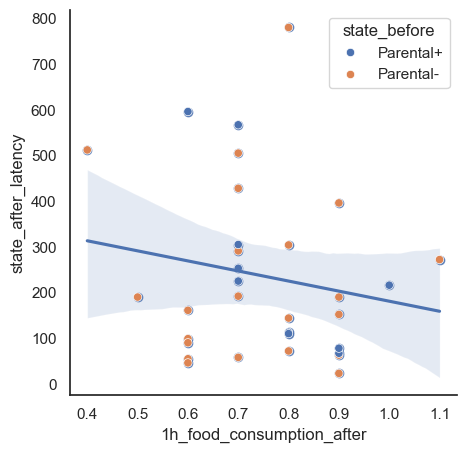

In [73]:
sns.set(rc={"figure.figsize": (5, 5)})
sns.set_style("white")


sns.regplot(
    x="1h_food_consumption_after", y="state_after_latency", data=agg_cond_data_first
)

sns.scatterplot(
    data=agg_cond_data_first,
    x="1h_food_consumption_after",
    y="state_after_latency",
    hue="state_before",
)
sns.despine()

plot regression line fit for relation between attack latency and food consumption

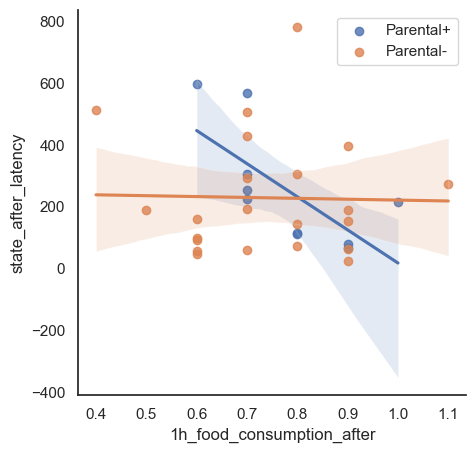

In [74]:
sns.set(rc={"figure.figsize": (5, 5)})
sns.set_style("white")

pos = sns.regplot(
    x="1h_food_consumption_after",
    y="state_after_latency",
    data=agg_cond_data_first[agg_cond_data_first["state_before"] == "Parental+"],
    label="Parental+",
)

neg = sns.regplot(
    x="1h_food_consumption_after",
    y="state_after_latency",
    data=agg_cond_data_first[agg_cond_data_first["state_before"] == "Parental-"],
    label="Parental-",
)

plt.legend()
sns.despine()

Investigate food consumption diff (new)

In [76]:
food_df = pd.read_csv("data/food_consumption.csv")
food_df = food_df[food_df.status == "use"]

model = smf.ols(
    "net_food ~ Behaviour", data=food_df[food_df.Behaviour != "nopup"]
).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)

# post-hoc test
from statsmodels.stats.multicomp import MultiComparison

mc = MultiComparison(
    food_df[food_df.Behaviour != "nopup"]["net_food"],
    food_df[food_df.Behaviour != "nopup"]["Behaviour"],
)
result = mc.tukeyhsd()
# get dof for tukey test

dof = len(food_df[food_df.Behaviour != "nopup"]) - food_df["Behaviour"].nunique()
print("Degrees of freedom:", dof)
# convert tukey result to dataframe
tukey_df = pd.DataFrame(
    data=result._results_table.data[1:],  # skip header row
    columns=result._results_table.data[0],
)
print(tukey_df)
print(result.pvalues)

             sum_sq    df          F        PR(>F)
Behaviour  3.299249   2.0  117.50878  6.245710e-18
Residual   0.589609  42.0        NaN           NaN
Degrees of freedom: 41
  group1    group2  meandiff   p-adj   lower   upper  reject
0   Agg+      Agg-   -0.1207  0.1719 -0.2809  0.0394   False
1   Agg+  baseline   -0.6488  0.0000 -0.7689 -0.5287    True
2   Agg-  baseline   -0.5281  0.0000 -0.6562 -0.4001    True
[1.71889439e-01 0.00000000e+00 3.16369153e-12]


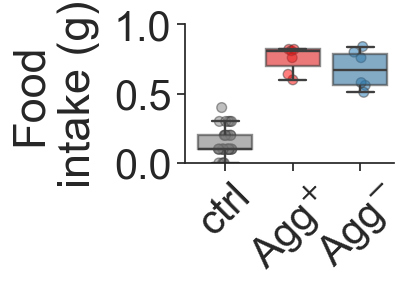

In [78]:
plt.subplots(figsize=(2.7, 1.8))
sns.set(font_scale=2.7)
sns.set_style("ticks")

g = sns.stripplot(
    x="Behaviour",
    y="net_food",
    data=food_df,
    order=["baseline", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["gray", "red", "Tab:blue"],
    alpha=0.5,
    zorder=1,
)
g = sns.boxplot(
    x="Behaviour",
    y="net_food",
    data=food_df,
    order=["baseline", "Agg+", "Agg-"],
    palette=["gray", "red", "Tab:blue"],
    linewidth=1.7,
    showfliers=False,
    boxprops=dict(alpha=0.6),
)

plt.ylabel("Food\nintake (g)", labelpad=10)
plt.xlabel("")
g.yaxis.set_major_locator(plt.MaxNLocator(2))
g.set_xticklabels(("ctrl", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

plt.ylim(0, 1)
plt.xlim(-0.6)
sns.despine(trim=False, bottom=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/food_consumption.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

# Target Specificity Analysis

### Predation Test 

Data extraction and reindexing

In [79]:
cricket_df = agg_cond_data_first[agg_cond_data_first["target"] == "cricket"]

cricket_data_before = (
    cricket_df.groupby(["state_after", "target_before"]).size().reset_index(name="n")
)
cricket_data_count = (
    cricket_df.groupby(["state_after"]).size().reset_index(name="count")
)
cricket_data_before = cricket_data_before.merge(
    cricket_data_count, how="outer", on="state_after"
)
cricket_data_after = (
    cricket_df.groupby(["state_after", "target_after"]).size().reset_index(name="n")
)
cricket_data_after = cricket_data_after.merge(
    cricket_data_count, how="outer", on="state_after"
)

cricket_data_before = cricket_data_before.rename(columns={"target_before": "target"})
cricket_data_after = cricket_data_after.rename(columns={"target_after": "target"})
cricket_data = pd.concat(
    [cricket_data_before, cricket_data_after], keys=["Pre", "Post"]
)
cricket_data.reset_index(inplace=True)
cricket_data["percent"] = (cricket_data["n"] / cricket_data["count"]) * 100

agg_plus_cricket = cricket_data[cricket_data["state_after"] == "Agg+"].reset_index()
agg_minus_cricket = cricket_data[cricket_data["state_after"] == "Agg-"].reset_index()

In [80]:
condition_df = pd.crosstab(
    cricket_df["state_after"], cricket_df["target_after"]
).reset_index()
stats.fisher_exact(condition_df.iloc[:, 1:])

SignificanceResult(statistic=3.3333333333333335, pvalue=0.5879120879120879)

In [81]:
condition_df = pd.crosstab(
    cricket_df["state_after"], cricket_df["target_after"], normalize="index"
).reset_index()
condition_df = condition_df.melt(id_vars="state_after", value_name="percent")
condition_df["percent"] = condition_df["percent"] * 100
condition_df

,state_after,target_after,percent
0,Agg+,Hunt+,40.000000
1,Agg-,Hunt+,16.666667
2,Agg+,Hunt-,60.000000
3,Agg-,Hunt-,83.333333


In [82]:
stats_df = pd.crosstab(
    cricket_df["state_after"], cricket_df["target_after"]
).reset_index()
stats.fisher_exact(stats_df.iloc[:, 1:])

SignificanceResult(statistic=3.3333333333333335, pvalue=0.5879120879120879)

([0, 1], [Text(0, 0, 'Agg+'), Text(1, 0, 'Agg-')])

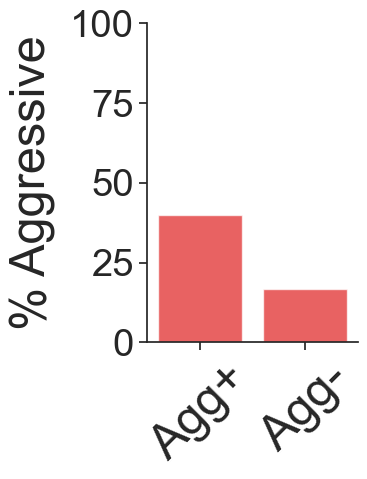

In [83]:
sns.set(font_scale=2.5)
sns.set_style("ticks")
g1 = sns.catplot(
    x="state_after",
    y="percent",
    data=condition_df[condition_df["target_after"] == "Hunt+"],
    kind="bar",
    palette=["red"],
    alpha=0.7,
    aspect=0.8,
)
plt.ylim([0, 100])
plt.ylabel("% Aggressive", fontsize=35, labelpad=10)
plt.xlabel("")
plt.xticks(fontsize=35, rotation=45)
# plt.savefig('/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure_1/linked_figure_S1/circket_cond_agg.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

calculate statistics of pre and post phase cricket hunt probabilities

In [84]:
plus_odds, plus_p = stats.fisher_exact(
    [
        [agg_plus_cricket.n[0], agg_plus_cricket.n[1]],
        [agg_plus_cricket.n[2], agg_plus_cricket.n[3]],
    ]
)

minus_odds, minus_p = stats.fisher_exact(
    [
        [agg_minus_cricket.n[0], agg_minus_cricket.n[1]],
        [agg_minus_cricket.n[2], agg_minus_cricket.n[3]],
    ]
)

print(plus_p, minus_p)

0.6284829721362228 1.0


data visualisation

In [85]:
# melt target_before and target_after into one column
cricket_melt = cricket_df.melt(
    id_vars=["mice_ID", "state_after"],
    value_vars=["target_before", "target_after"],
    var_name="state",
    value_name="cricket_agg",
)
crossed_tab = pd.crosstab(
    cricket_melt["state"], cricket_melt["cricket_agg"], 
).reset_index()
print(crossed_tab)

print(fisher_exact(crossed_tab.iloc[:, 1:]))

# transform to percentage
# normalize each row to sum to 1
crossed_tab = crossed_tab.set_index("state").T
crossed_tab = crossed_tab.div(crossed_tab.sum(axis=0), axis = 1).T.reset_index()
crossed_tab["Hunt+"] = crossed_tab["Hunt+"] * 100
crossed_tab["Hunt-"] = crossed_tab["Hunt-"] * 100

cricket_agg          state  Hunt+  Hunt-
0             target_after      5     11
1            target_before      3     13
SignificanceResult(statistic=1.9696969696969697, pvalue=0.685082190087752)


(0.0, 100.0)

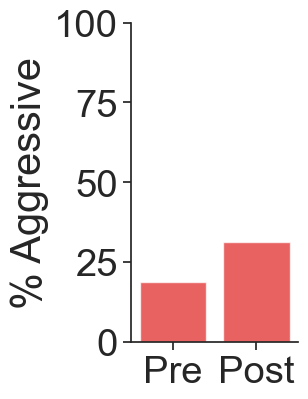

In [87]:
sns.set(font_scale=2.5)
sns.set_style("ticks")

g1 = sns.catplot(
    x="state",
    y="Hunt+",
    data=crossed_tab,
    kind="bar",
    palette=["red"],
    alpha=0.7,
    aspect=0.8,
    order=['target_before', 'target_after'],
)

g1.set(xlabel=None)
g1.set(ylabel="% Aggressive")
g1.set_xticklabels(["Pre", "Post"])
plt.ylim([0, 100])


# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/cricket.pdf',
#             dpi = 600, bbox_inches='tight',transparent=True)

### Intruder test
<br>
data extraction and reindexing

In [88]:
intruder_data = agg_cond_data_first[agg_cond_data_first["target"] == "intruder"]
intruder_data_tb = (
    intruder_data.groupby(["state_after", "target_before"]).size().reset_index(name="n")
)
intruder_data_ta = (
    intruder_data.groupby(["state_after", "target_after"]).size().reset_index(name="n")
)
intruder_data_tb = intruder_data_tb.rename(columns={"target_before": "target"})
intruder_data_ta = intruder_data_ta.rename(columns={"target_after": "target"})
intruder_data_t = pd.concat([intruder_data_tb, intruder_data_ta], keys=["Pre", "Post"])
intruder_data_t.reset_index(inplace=True)
ls = intruder_data_t.columns.tolist()

Agg_t = pd.DataFrame(
    [
        ["Pre", "0", "Agg+", "Agg+", 0],
        ["Post", "1", "Agg+", "Agg+", 0],
        ["Pre", "0", "Agg-", "Agg+", 0],
        ["Post", "1", "Agg-", "Agg+", 0],
    ],
    columns=ls,
)

intruder_data_t = pd.concat([intruder_data_t, Agg_t])

intruder_data_t2b = (
    intruder_data.groupby(["state_after", "target_2_before"])
    .size()
    .reset_index(name="n")
)
intruder_data_t2a = (
    intruder_data.groupby(["state_after", "target_2_after"])
    .size()
    .reset_index(name="n")
)
intruder_data_t2b = intruder_data_t2b.rename(columns={"target_2_before": "target"})
intruder_data_t2a = intruder_data_t2a.rename(columns={"target_2_after": "target"})
intruder_data_t2 = pd.concat(
    [intruder_data_t2b, intruder_data_t2a], keys=["Pre", "Post"]
)
intruder_data_t2.reset_index(inplace=True)
Agg_t2 = pd.DataFrame(
    [
        ["Pre", "0", "Agg+", "Agg+", 0],
        ["Post", "1", "Agg+", "Agg+", 0],
        ["Pre", "0", "Agg-", "Agg+", 0],
        ["Post", "1", "Agg-", "Agg+", 0],
    ],
    columns=ls,
)
intruder_data_t2 = pd.concat([intruder_data_t2, Agg_t2])


intruder_data_count = (
    intruder_data.groupby(["state_after"]).size().reset_index(name="count")
)
intruder_data_t = intruder_data_t.merge(
    intruder_data_count, how="outer", on="state_after"
)
intruder_data_t2 = intruder_data_t2.merge(
    intruder_data_count, how="outer", on="state_after"
)

intruder_data_t["percent"] = (intruder_data_t["n"] / intruder_data_t["count"]) * 100
intruder_data_t2["percent"] = (intruder_data_t2["n"] / intruder_data_t2["count"]) * 100

In [89]:
melted_intruder = intruder_data.melt(
    id_vars=["mice_ID", "state_after"],
    value_vars=["target_before", "target_after", "target_2_before", "target_2_after"],
    var_name="state",
    value_name="intruder_agg",
)

# test['level_1'] = test['level_1'].astype(int)

In [90]:
intruder_a = melted_intruder[melted_intruder.state.isin(['target_before', 'target_after'])]


In [91]:
crossed_a = pd.crosstab(intruder_a["state"], intruder_a["intruder_agg"])
crossed_a['Agg+'] = 0

In [92]:
fisher_exact(crossed_a +1)

SignificanceResult(statistic=1.0, pvalue=1.0)

intruder test data visualization (male and female intruders)

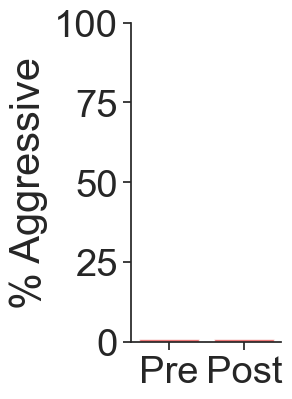

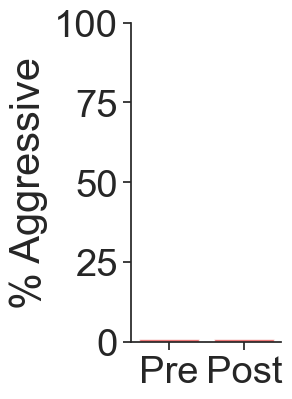

In [94]:
sns.set(font_scale=2.5)
sns.set_style("ticks")

intruder_data_t = intruder_data_t.rename(columns={"state_after": "Post state"})
intruder_data_t = intruder_data_t[
    (intruder_data_t["Post state"] == "Agg+") & (intruder_data_t.target == "Agg+")
]

# add small const. value to 0 values so that columns become visible
small_value = 1
intruder_data_t.loc[intruder_data_t["percent"] == 0, "percent"] += small_value

g1 = sns.catplot(
    x="level_0",
    y="percent",
    hue="target",
    data=intruder_data_t,
    kind="bar",
    palette=["red"],
    alpha=0.7,
    aspect=0.8,
)

# autolabel(g1, intruder_data_t['count'].tolist())
g1.set(xlabel=None)
g1.set(ylabel="% Aggressive")
plt.ylim([0, 100])
g1._legend.remove()

g1._legend.set_title(None)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/female intruder.pdf",
#     dpi=600,
#     bbox_inches="tight",
#     transparent=True,
# )

intruder_data_t2 = intruder_data_t2.rename(columns={"state_after": "Post state"})
intruder_data_t2 = intruder_data_t2.rename(columns={"state_after": "Post state"})
intruder_data_t2 = intruder_data_t2[
    (intruder_data_t2["Post state"] == "Agg+") & (intruder_data_t2.target == "Agg+")
]

# add small const. value to 0 values so that columns become visible
intruder_data_t2.loc[intruder_data_t2["percent"] == 0, "percent"] += small_value

g2 = sns.catplot(
    x="level_0",
    y="percent",
    hue="target",
    data=intruder_data_t2,
    kind="bar",
    palette=["red"],
    alpha=0.7,
    aspect=0.8,
)

g2._legend.set_title(None)
g2._legend.remove()
# autolabel(g2, intruder_data_t2['count'].tolist()) # display number of mice in each group
g2.set(xlabel=None)
plt.ylim([0, 100])
g2.set(ylabel="% Aggressive")
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/male intruder.pdf",
#     dpi=600,
#     bbox_inches="tight",
#     transparent=True,
# )

# Elevated Plus Maze

extract and clean maze data from EthoVision output

In [96]:
maze_data = pd.read_excel("data/Statistics-plus_maze_2601.xlsx", engine="openpyxl")
ID = [
    "BRAC5018.4d",
    "BRAC5018.4e",
    "BRAC5048.5c",
    "BRAC5048.5d",
    "BRAC5048.5e",
    "BRAC5081.3c",
    "BRAC5081.3d",
    "BRAC5081.3e",
    "BRAC5195.3c",
    "BRAC5195.3d",
    "BRAC5195.3e",
    "BRAC5204.2h",
    "BRAC5081.3c",
    "BRAC5018.4d",
    "BRAC5018.4e",
    "BRAC5048.5c",
    "BRAC5048.5d",
    "BRAC5048.5e",
    "BRAC5081.3d",
    "BRAC5081.3e",
    "BRAC5195.3c",
    "BRAC5195.3d",
    "BRAC5195.3e",
    "BRAC5204.2h",
    "BRAC5204.2i",
    "BRAC5204.2j",
    "BRAC5266.1f",
    "BRAC5266.1g",
]

maze_data_0 = maze_data[maze_data["result"].isin(["Result 1", "Result 1 (2)"])]
maze_data = maze_data.loc[maze_data["result"].isin(["Pre", "Post"])]
maze_data["mice_ID"] = ID
maze_data_merge = pd.merge(maze_data, agg_cond_data_first, how="left", on="mice_ID")
maze_data_merge_t = pd.merge(maze_data_merge, maze_data_0, how="left", on="trial")

calculate statistical difference between Agg+ and Agg- in terms of anxiety related parameters

In [97]:
maze_data_merge["ratio"] = maze_data_merge[
    "In open arms open_arm / center-point Cumulative Duration s"
].div(maze_data_merge["In closed arms closed_arm / center-point Cumulative Duration s"])

maze_control = maze_data_merge[maze_data_merge["result"] == "Pre"]
maze_test = maze_data_merge[maze_data_merge["result"] == "Post"]

stats_b, p_b = stats.ttest_ind(
    maze_control[maze_control["state_after"] == "Agg+"]["ratio"],
    maze_control[maze_control["state_after"] == "Agg-"]["ratio"],
    equal_var=False,
)

stats_a, p_a = stats.ttest_ind(
    maze_test[maze_test["state_after"] == "Agg+"]["ratio"],
    maze_test[maze_test["state_after"] == "Agg-"]["ratio"],
    equal_var=False,
)

stats_plus, p_plus = stats.ttest_ind(
    maze_control[maze_control["state_after"] == "Agg+"]["ratio"],
    maze_test[maze_test["state_after"] == "Agg+"]["ratio"],
    equal_var=False,
)

stats_minus, p_minus = stats.ttest_ind(
    maze_control[maze_control["state_after"] == "Agg-"]["ratio"],
    maze_test[maze_test["state_after"] == "Agg-"]["ratio"],
    equal_var=False,
)
print(p_b, p_a, p_plus, p_minus)

0.8264208087067954 0.7220669520605643 0.42629904467606594 0.16138638571120453


In [98]:
# two-way ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

maze_data_merge["state_after"] = pd.Categorical(
    maze_data_merge["state_after"], ["Agg+", "Agg-"]
)
maze_data_merge["result"] = pd.Categorical(maze_data_merge["result"], ["Pre", "Post"])

model = ols(
    "ratio ~ C(state_after) + C(result) + C(state_after):C(result) ",
    data=maze_data_merge,
).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                             sum_sq    df         F    PR(>F)
C(state_after)             0.081362   1.0  0.098517  0.756328
C(result)                  2.231250   1.0  2.701704  0.113279
C(state_after):C(result)   0.027061   1.0  0.032766  0.857876
Residual                  19.820826  24.0       NaN       NaN


calculate statistical difference between spontaneous Parental+ and Parental- in terms of anxiety related parameters

In [99]:
stats_b_p, p_b_p = stats.ttest_ind(
    maze_control[maze_control["state_before"] == "Parental+"]["ratio"],
    maze_control[maze_control["state_before"] == "Parental-"]["ratio"],
    equal_var=False,
)

stats_a_p, p_a_p = stats.ttest_ind(
    maze_test[maze_test["state_before"] == "Parental+"]["ratio"],
    maze_test[maze_test["state_before"] == "Parental-"]["ratio"],
    equal_var=False,
)

stats_p, p_p = stats.ttest_ind(
    maze_control[maze_control["state_before"] == "Parental+"]["ratio"],
    maze_test[maze_test["state_before"] == "Parental+"]["ratio"],
    equal_var=False,
)

print(p_b_p, p_a_p, p_p)

0.12388124917081016 0.25462453336622937 0.27666604506360143


visualization of various elevated_pluz_maze related parameters between Agg+ and Agg- groups

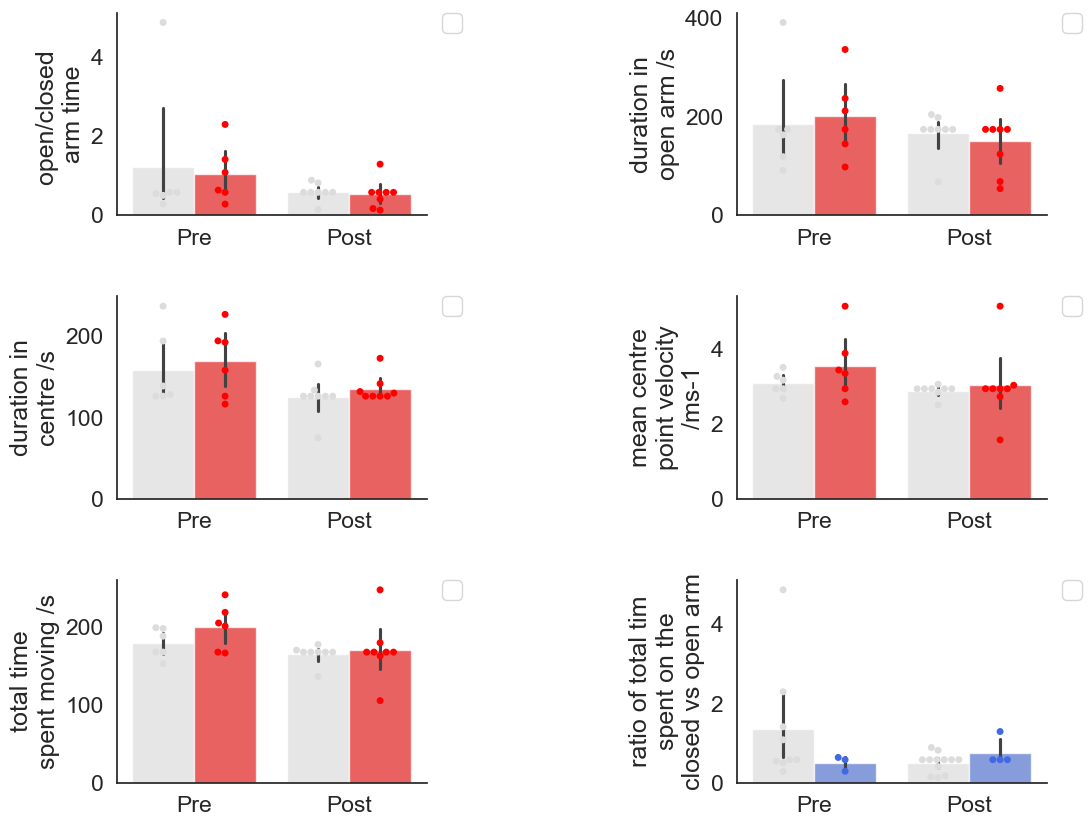

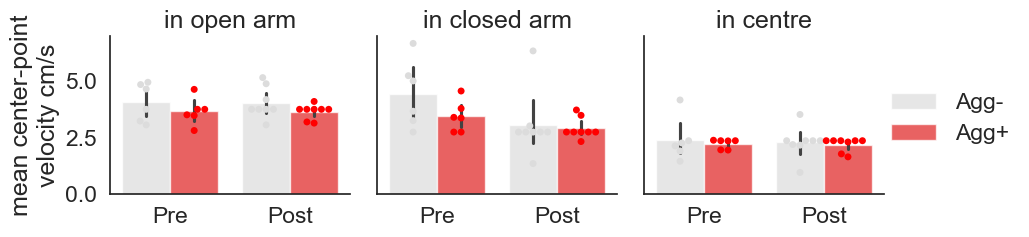

In [100]:
fig = plt.figure(figsize=(12, 10))
n = [6, 8, 6, 8]
sns.set(font_scale=1.5)
sns.set_style("white")
ax1 = fig.add_subplot(321)
category_plotting_2(
    "result", "ratio", "state_after", maze_data_merge, ax1, ["gainsboro", "red"]
)
ax1.set(ylabel="open/closed \narm time")
ax1.set_xlabel("")
# autolabel_2(ax1, n)
plt.savefig("elevated_plus_maze.jpg", dpi=300)

ax2 = fig.add_subplot(322)
category_plotting_2(
    "result",
    "In open arms open_arm / center-point Cumulative Duration s",
    "state_after",
    maze_data_merge,
    ax2,
    ["gainsboro", "red"],
)
ax2.set(ylabel="duration in\nopen arm /s")
ax2.set_xlabel("")
# autolabel_2(ax2, n)

ax3 = fig.add_subplot(323)
category_plotting_2(
    "result",
    "In zone centre / center-point Cumulative Duration s",
    "state_after",
    maze_data_merge,
    ax3,
    ["gainsboro", "red"],
)
ax3.set(ylabel="duration in\ncentre /s")
ax3.set_xlabel("")
# autolabel_2(ax3, n)

ax4 = fig.add_subplot(324)
category_plotting_2(
    "result",
    "Velocity center-point Mean cm/s",
    "state_after",
    maze_data_merge,
    ax4,
    ["gainsboro", "red"],
)
ax4.set(ylabel="mean centre\npoint velocity\n/ms-1")
ax4.set_xlabel("")
# autolabel_2(ax4, n)

ax5 = fig.add_subplot(325)
category_plotting_2(
    "result",
    "Movement Moving / center-point Cumulative Duration s",
    "state_after",
    maze_data_merge,
    ax5,
    ["gainsboro", "red"],
)
ax5.set(ylabel="total time\nspent moving /s")
ax5.set_xlabel("")
# autolabel_2(ax5, n)

ax6 = fig.add_subplot(326)
category_plotting_2(
    "result", "ratio", "state_before", maze_data_merge, ax6, ["gainsboro", "royalblue"]
)
fig.subplots_adjust(wspace=0.7)
ax6.set(ylabel="ratio of total tim\nspent on the\nclosed vs open arm")
ax6.set_xlabel("")
# autolabel_2(ax6, n)

plt.subplots_adjust(hspace=0.4, wspace=1.0)
maze_data_merge_t = maze_data_merge_t.replace(
    to_replace="For center-point in open_arm", value="open"
)
maze_data_merge_t = maze_data_merge_t.replace(
    to_replace="For center-point in closed_arm", value="closed"
)
maze_data_merge_t = maze_data_merge_t.replace(
    to_replace="For center-point in centre", value="centre"
)
g = sns.FacetGrid(maze_data_merge_t, col="area_y", legend_out=True)
g.map(
    sns.swarmplot,
    "result_x",
    "Velocity center-point Mean cm/s_y",
    "state_after",
    palette=["gainsboro", "red"],
    dodge=True,
)
g.map(
    sns.barplot,
    "result_x",
    "Velocity center-point Mean cm/s_y",
    "state_after",
    alpha=0.7,
    palette=["gainsboro", "red"],
)
g.axes[0, 0].set_xlabel("")
g.axes[0, 0].set_title("in open arm")
g.axes[0, 1].set_xlabel("")
g.axes[0, 1].set_title("in closed arm")
g.axes[0, 2].set_xlabel("")
g.axes[0, 2].set_title("in centre")
g.axes[0, 0].set(ylabel="mean center-point\nvelocity cm/s")
g.add_legend()

# Openfield analysis


In [101]:
open_data = pd.read_excel("data/Statistics-MC_openfield.xlsx", engine="openpyxl")
open_data = open_data.loc[open_data["state"].isin(["Pre", "Post"])]
open_ID = [
    "BRAC5370.6e",
    "BRAC5491.5f",
    "BRAC5539.5g",
    "BRAC5539.5h",
    "BRAC5539.5i",
    "BRAC5626.4e",
    "BRAC5626.4f",
    "BRAC5626.4g",
    "BRAC5626.4h",
    "BRAC5679.4b",
    "BRAC5679.4c",
    "BRAC5740.4d",
    "BRAC5801.3c",
    "BRAC5801.3d",
    "BRAC5801.3e",
    "BRAC5801.3f",
    "BRAC5858.2g",
    "BRAC5370.6e",
    "BRAC5491.5f",
    "BRAC5539.5g",
    "BRAC5539.5h",
    "BRAC5539.5i",
    "BRAC5626.4e",
    "BRAC5626.4f",
    "BRAC5626.4g",
    "BRAC5626.4h",
    "BRAC5679.4b",
    "BRAC5679.4c",
    "BRAC5740.4d",
    "BRAC5801.3c",
    "BRAC5801.3d",
    "BRAC5801.3e",
    "BRAC5801.3f",
    "BRAC5858.2g",
]

open_data["mice_ID"] = open_ID
open_data_merge = pd.merge(open_data, agg_cond_data_first, how="left", on="mice_ID")

In [102]:
open_data_merge["ratio"] = open_data_merge[
    "In zone centre / center-point Cumulative Duration s"
].div(600)
open_control = open_data_merge[open_data_merge["state"] == "Pre"]
open_test = open_data_merge[open_data_merge["state"] == "Post"]

stats_b, p_b = stats.ttest_ind(
    open_control[open_control["state_after"] == "Agg+"]["ratio"],
    open_control[open_control["state_after"] == "Agg-"]["ratio"],
    equal_var=False,
)

stats_a, p_a = stats.ttest_ind(
    open_test[open_test["state_after"] == "Agg+"]["ratio"],
    open_test[open_test["state_after"] == "Agg-"]["ratio"],
    equal_var=False,
)

stats_plus, p_plus = stats.ttest_ind(
    open_control[open_control["state_after"] == "Agg+"]["ratio"],
    open_test[open_test["state_after"] == "Agg+"]["ratio"],
    equal_var=False,
)

stats_minus, p_minus = stats.ttest_ind(
    open_control[open_control["state_after"] == "Agg-"]["ratio"],
    open_test[open_test["state_after"] == "Agg-"]["ratio"],
    equal_var=False,
)
print(p_b, p_a, p_plus, p_minus)

0.9841385621824104 0.9484796443263936 0.7365364150422467 0.8744435335032055


In [103]:
# two-way ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

open_data_merge["state_after"] = pd.Categorical(
    open_data_merge["state_after"], ["Agg+", "Agg-"]
)
open_data_merge["result"] = pd.Categorical(open_data_merge["state"], ["Pre", "Post"])

model = ols(
    "ratio ~ C(state_after) + C(state) + C(state_after):C(state) ", data=open_data_merge
).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                           sum_sq    df         F    PR(>F)
C(state_after)           0.000039   1.0  0.004618  0.946273
C(state)                 0.001015   1.0  0.120278  0.731154
C(state_after):C(state)  0.000014   1.0  0.001630  0.968062
Residual                 0.253040  30.0       NaN       NaN


Text(0.5, 71.24999999999999, '')

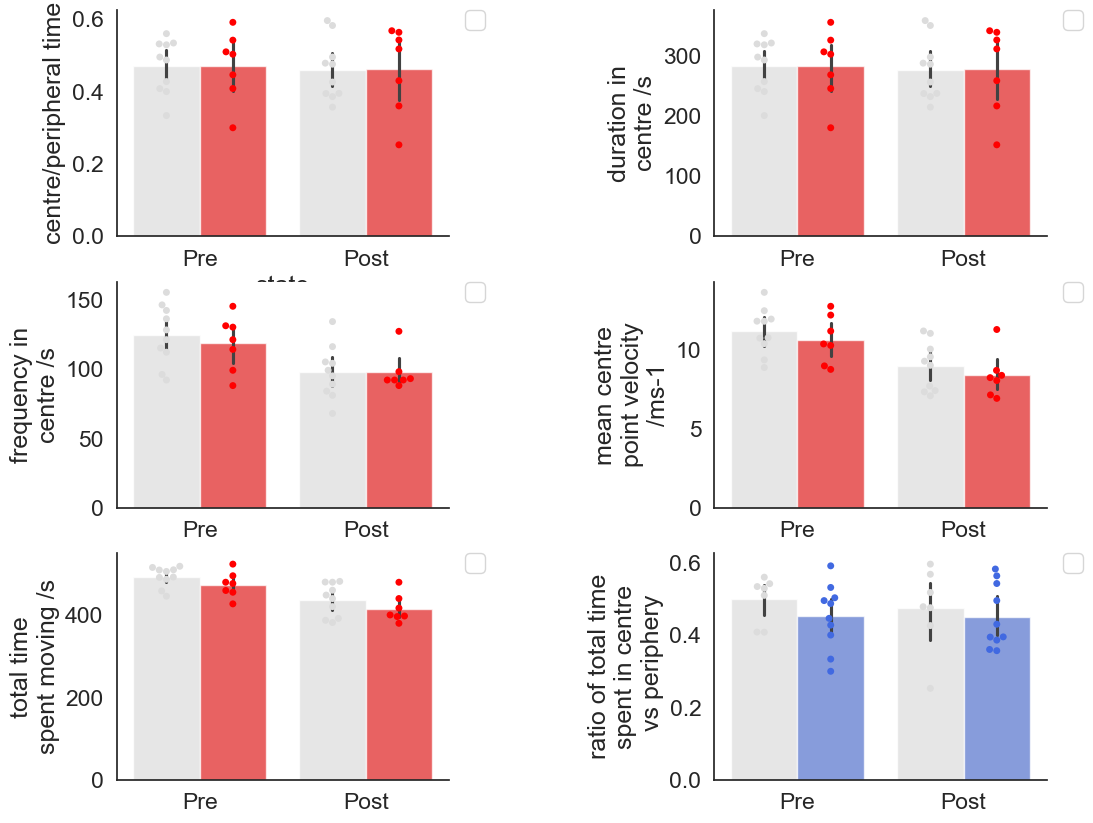

In [104]:
fig = plt.figure(figsize=(12, 10))
n = [7, 7, 10, 10]
sns.set(font_scale=1.5)
sns.set_style("white")
ax1 = fig.add_subplot(321)
category_plotting_2(
    "state", "ratio", "state_after", open_data_merge, ax1, ["gainsboro", "red"]
)
ax1.set(ylabel="centre/peripheral time")
# autolabel_2(ax1, n)
plt.savefig("openfield.jpg", dpi=300)

ax2 = fig.add_subplot(322)
category_plotting_2(
    "state",
    "In zone centre / center-point Cumulative Duration s",
    "state_after",
    open_data_merge,
    ax2,
    ["gainsboro", "red"],
)
ax2.set(ylabel="duration in\ncentre /s")
ax2.set_xlabel("")
# autolabel_2(ax2, n)

ax3 = fig.add_subplot(323)
category_plotting_2(
    "state",
    "In zone centre / center-point Frequency",
    "state_after",
    open_data_merge,
    ax3,
    ["gainsboro", "red"],
)
ax3.set(ylabel="frequency in\ncentre /s")
ax3.set_xlabel("")
# autolabel_2(ax3, n)

ax4 = fig.add_subplot(324)
category_plotting_2(
    "state",
    "Velocity center-point Mean cm/s",
    "state_after",
    open_data_merge,
    ax4,
    ["gainsboro", "red"],
)
ax4.set(ylabel="mean centre\npoint velocity\n/ms-1")
ax4.set_xlabel("")
# autolabel_2(ax4, n)

ax5 = fig.add_subplot(325)
category_plotting_2(
    "state",
    "Movement Moving / center-point Cumulative Duration s",
    "state_after",
    open_data_merge,
    ax5,
    ["gainsboro", "red"],
)
ax5.set(ylabel="total time\nspent moving /s")
ax5.set_xlabel("")
# autolabel_2(ax5, n)

ax6 = fig.add_subplot(326)
category_plotting_2(
    "state", "ratio", "state_before", open_data_merge, ax6, ["gainsboro", "royalblue"]
)
fig.subplots_adjust(wspace=0.8)
ax6.set(ylabel="ratio of total time\nspent in centre\n vs periphery")
ax6.set_xlabel("")
# autolabel_2(ax6, n)

# Baseline activity examination

baseline data extraction and merging

In [105]:
base_data = pd.read_csv("data/Statistics-baseline_MC+2.csv")
base_data["mice_ID"] = ID
base_data["moving ratio"] = base_data[
    "Movement Moving / center-point Cumulative Duration"
].div(base_data["in Arena Arena / center-point Cumulative Duration"])
base_data_merge = pd.merge(base_data, agg_cond_data_first, how="left", on="mice_ID")

calculating stats for baseline parameters - comparing pre and post state 

In [106]:
parameters = [
    "Distance moved center-point Total",
    "Velocity center-point Mean",
    "moving ratio",
    "In centre centre / center-point Cumulative Duration",
    "Distance to zone centre / center-point Mean",
]

for param in parameters:
    stats_base, p_base = stats.ttest_ind(
        base_data_merge[maze_data_merge["state_after"] == "Agg+"][param],
        base_data_merge[maze_data_merge["state_after"] == "Agg-"][param],
        equal_var=False,
    )
    print(param, p_base)

Distance moved center-point Total 0.15241728721814812
Velocity center-point Mean 0.1495017559202885
moving ratio 0.1551939281171604
In centre centre / center-point Cumulative Duration 0.6605170186770086
Distance to zone centre / center-point Mean 0.18292826317963348


visualizing baseline parameters of Agg+ and Agg- groups

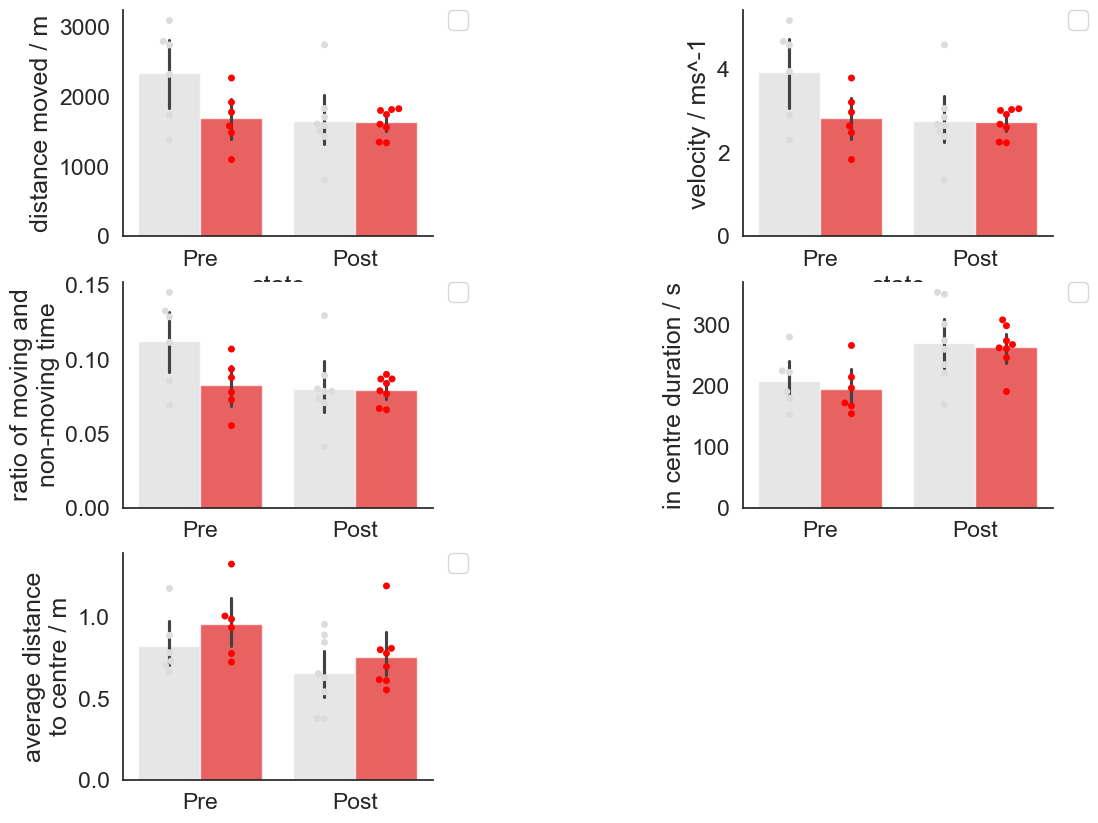

In [108]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(321)
category_plotting_2(
    "state",
    "Distance moved center-point Total",
    "state_after",
    base_data_merge,
    ax1,
    ["gainsboro", "red"],
)
ax1.set(ylabel="distance moved / m")


ax2 = fig.add_subplot(322)
category_plotting_2(
    "state",
    "Velocity center-point Mean",
    "state_after",
    base_data_merge,
    ax2,
    ["gainsboro", "red"],
)
ax2.set(ylabel="velocity / ms^-1")

ax3 = fig.add_subplot(323)
category_plotting_2(
    "state", "moving ratio", "state_after", base_data_merge, ax3, ["gainsboro", "red"]
)
ax3.set(ylabel="ratio of moving and\nnon-moving time")
ax3.set_xlabel("")


ax4 = fig.add_subplot(324)
category_plotting_2(
    "state",
    "In centre centre / center-point Cumulative Duration",
    "state_after",
    base_data_merge,
    ax4,
    ["gainsboro", "red"],
)
ax4.set(ylabel="in centre duration / s")
ax4.set_xlabel("")


ax5 = fig.add_subplot(325)
category_plotting_2(
    "state",
    "Distance to zone centre / center-point Mean",
    "state_after",
    base_data_merge,
    ax5,
    ["gainsboro", "red"],
)
ax5.set(ylabel="average distance\nto centre / m")
ax5.set_xlabel("")


fig.subplots_adjust(wspace=1.0)

# Refeeding Experiment

import data from refeeding experiment

In [110]:
refeeding_dat = pd.read_csv("data/NPW_refeeding.csv")
refeeding_dat["state"] = "competitive_assay"
ob_per = refeeding_dat.groupby(["state", "object_state"]).size().reset_index(name="n")
fd_per = refeeding_dat.groupby(["state", "food_state"]).size().reset_index(name="n")

ob_per["count"] = ob_per["n"].sum()
ob_per["percentage"] = ob_per["n"] / ob_per["count"] * 100
ob_per = ob_per.rename(columns={"object_state": "refeeding_state"})
ob_per["state"] = "object in"


fd_per["count"] = fd_per["n"].sum()
fd_per["percentage"] = fd_per["n"] / fd_per["count"] * 100
fd_per = fd_per.rename(columns={"food_state": "refeeding_state"})
fd_per["state"] = "food in"


refeeding_plot = pd.concat([ob_per, fd_per])
refeeding_plot = refeeding_plot[refeeding_plot["refeeding_state"] == "Agg+"]
print(refeeding_plot)

       state refeeding_state  n  count  percentage
0  object in            Agg+  8     10        80.0
0    food in            Agg+  1     10        10.0


In [111]:
object_num = refeeding_plot[refeeding_plot.state == "object in"]["n"].iloc[0]
food_num = refeeding_plot[refeeding_plot.state == "food in"]["n"].iloc[0]
total_num = 10

_, p1, _, _ = stats.chi2_contingency(
    [[total_num, 0], [object_num, total_num - object_num]]
)
_, p2, _, _ = stats.chi2_contingency([[total_num, 0], [food_num, total_num - food_num]])
print(p1, p2)

print(stats.chi2_contingency([[total_num, 0], [food_num, total_num - food_num]]))

0.456056540250256 0.0003234799467258457
Chi2ContingencyResult(statistic=12.929292929292929, pvalue=0.0003234799467258457, dof=1, expected_freq=array([[5.5, 4.5],
       [5.5, 4.5]]))


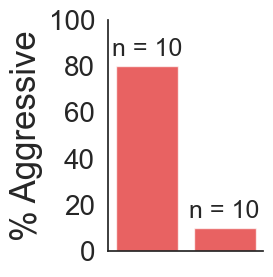

In [112]:
plt.subplots(figsize=(2, 3))
g = sns.barplot(
    x="state", y="percentage", data=refeeding_plot, alpha=0.7, palette=["red"]
)


plt.ylabel("% Aggressive", fontsize=25)
plt.xlabel("")
plt.xticks([], [], fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(0, 100)
sns.despine()

i = 0
for p in g.patches:
    g.annotate(
        "n = " + str(refeeding_plot["count"].tolist()[i]),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 12),
        textcoords="offset points",
        fontsize=18,
    )
    i = i + 1


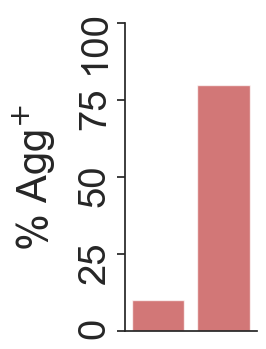

In [113]:
sns.set(rc={"figure.figsize": (1.7, 4)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    x="state",
    y="percentage",
    data=refeeding_plot,
    order=["food in", "object in"],
    alpha=0.7,
    palette=["Tab:red"],
)


plt.ylabel(r"% Agg$^{+}$", labelpad=15)
plt.xlabel("")
plt.xticks([])
plt.yticks(rotation=90)
plt.locator_params(axis="y", nbins=4)
plt.ylim(0, 100)
sns.despine()

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/competition.pdf',bbox_inches='tight')

In [114]:
from lifelines import AalenJohansenFitter

food_df = refeeding_dat[refeeding_dat.state.isin(["refeeding_1h", "competitive_assay"])]
food_df = food_df.loc[:, ["mice_ID", "food_state", "food_state_latency"]]
object_df = refeeding_dat[
    refeeding_dat.state.isin(["refeeding_1h", "competitive_assay"])
]
object_df = object_df.loc[:, ["mice_ID", "object_state", "object_state_latency"]]

food_df.loc[food_df.food_state == "Agg-", "food_state_latency"] = 6 * 60
food_df["aggression_binary"] = food_df.food_state.apply(
    lambda x: 1 if x == "Agg+" else 0
)
object_df.loc[object_df.object_state == "Agg-", "object_state_latency"] = 6 * 60
object_df["aggression_binary"] = object_df.object_state.apply(
    lambda x: 1 if x == "Agg+" else 0
)

food_df = food_df.dropna()
object_df = object_df.dropna()

Text(0, 0.5, 'Aggression (CD)')

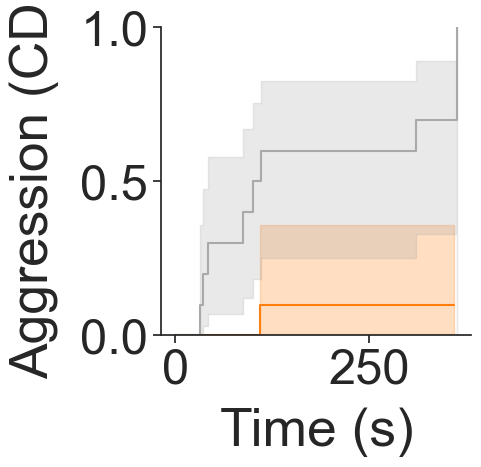

In [115]:
sns.set(rc={"figure.figsize": (4, 4)})
sns.set(font_scale=3.2)
sns.set_style("ticks")
sns.set_palette(["Tab:orange", "darkgray"])  # vs food / vs object

ajf_food = AalenJohansenFitter(calculate_variance=True)
ajf_food.fit(food_df.food_state_latency, food_df.aggression_binary, event_of_interest=1)
ajf_food.cumulative_density_
ajf_food.plot()

ajf_object = AalenJohansenFitter(calculate_variance=True)
ajf_object.fit(
    object_df.object_state_latency, object_df.aggression_binary, event_of_interest=1
)
ajf_object.cumulative_density_
ajf_object.plot()

# get the legend handle of the plot
# handles, labels = plt.gca().get_legend_handles_labels()
# create a new legend from the last two handles
# plt.legend(handles[::], ['vs food', 'vs object'], bbox_to_anchor=(0.3, 1.4), loc='upper left', borderaxespad=0., fontsize = 20)
plt.legend([], [], frameon=False)
sns.despine()
plt.ylim([0, 1])
plt.xlabel("Time (s)", labelpad=10)
plt.ylabel("Aggression (CD)", labelpad=15)
# plt.xticks(np.arange(0, 901, 450))
# plt.xlim(0,900)
# plt.savefig('output_figures/competitive_assay_survival.pdf', dpi=300,bbox_inches='tight')
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/competitive_assay_survival.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )

In [116]:
from lifelines.statistics import logrank_test

results = logrank_test(
    food_df.food_state_latency,
    object_df.object_state_latency,
    event_observed_A=food_df.aggression_binary,
    event_observed_B=object_df.aggression_binary,
)
results.print_summary()
print("Log-Rank Test p-value:", results.p_value)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           7.64 0.01      7.45

Log-Rank Test p-value: 0.00571692715027483
